In [20]:
#!pip install fastexcel

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   -------------------------------------- - 1.0/1.1 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 8.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import polars as pl
import pandas as pd

import requests, io, zipfile, json, plotnine,\
        string, random, chardet, calendar,\
        json, pprint

# Begin

## Introducing Polars

https://s3.amazonaws.com/tripdata/202403-citibike-tripdata.csv.zip

In [2]:
trips = (
    pl
        .read_csv(
            zipfile
                .ZipFile(
                    io.BytesIO(
                        requests.get('https://s3.amazonaws.com/tripdata/202403-citibike-tripdata.csv.zip').content))
                .open('202403-citibike-tripdata.csv'),
            try_parse_dates=True,
            schema_overrides=dict(
                start_station_id=pl.String, 
                end_station_id=pl.String))
        .sort(
            'started_at'
        )
); trips

ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
str,str,datetime[μs],datetime[μs],str,str,str,str,f64,f64,f64,f64,str
"""9EC2AD5F3F8C8B57""","""classic_bike""",2024-02-29 00:20:27.570,2024-03-01 01:20:22.196,"""61 St & 39 Ave""","""6307.07""",null,null,40.7471,-73.9028,null,null,"""member"""
"""C76D82D96516BDC2""","""classic_bike""",2024-02-29 07:54:34.223,2024-03-01 08:54:12.611,"""E 54 St & 1 Ave""","""6608.09""",null,null,40.756265,-73.964179,null,null,"""member"""
"""B4C73C958C65FEA6""","""electric_bike""",2024-02-29 08:47:09.664,2024-03-01 09:47:02.393,"""FDR Drive & E 35 St""","""6230.04""",null,null,40.744219,-73.971212,null,null,"""member"""
"""E23F7822B3D53E2A""","""classic_bike""",2024-02-29 09:57:07.150,2024-03-01 10:57:00.848,"""E 6 St & Ave B""","""5584.04""",null,null,40.724537,-73.981854,null,null,"""member"""
"""B0B6437C50C3AB3E""","""electric_bike""",2024-02-29 10:29:41.981,2024-03-01 11:29:21.539,"""Eastern Pkwy & Brooklyn Ave""","""3871.02""",null,null,40.66939,-73.94514,null,null,"""member"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""197C0ABDD3348135""","""classic_bike""",2024-03-31 23:55:37.938,2024-03-31 23:59:08.301,"""E 59 St & Madison Ave""","""6801.01""","""3 Ave & E 62 St""","""6762.04""",40.763505,-73.971092,40.763126,-73.965269,"""member"""
"""702FEBD6D9CCE4BC""","""classic_bike""",2024-03-31 23:55:40.087,2024-03-31 23:57:26.335,"""Amsterdam Ave & W 119 St""","""7727.07""","""Morningside Ave & W 123 St""","""7741.01""",40.808625,-73.959621,40.81,-73.955151,"""member"""
"""ECA4FC65950ADDDB""","""electric_bike""",2024-03-31 23:55:41.173,2024-03-31 23:57:25.079,"""S 4 St & Wythe Ave""","""5204.05""","""S 3 St & Bedford Ave""","""5235.05""",40.712996,-73.965971,40.712605,-73.962644,"""member"""


https://github.com/HodgesWardElliott/custom-nyc-neighborhoods/

In [3]:
neighborhoods = (
    pl
        .read_json(
            io.BytesIO(
                requests
                    .get(
                        url='https://raw.githubusercontent.com/HodgesWardElliott/custom-nyc-neighborhoods/refs/heads/master/custom-pedia-cities-nyc-Mar2018.geojson',
                        verify=False)
                    .content))
        .select('features')
        .explode('features')
        .unnest('features')
        .unnest('properties')
        .select('neighborhood', 'borough', 'geometry')
        .unnest('geometry')
        .with_columns(polygon=pl.col('coordinates').list.first())
        .select('neighborhood', 'borough', 'polygon')
        .filter(pl.col('borough') != 'Staten Island')
        .sort('neighborhood')
); neighborhoods

C:\Users\seliverstovdi\AppData\Roaming\Python\Python313\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings


neighborhood,borough,polygon
str,str,list[list[f64]]
"""Allerton""","""Bronx""","[[-73.848597, 40.87167], [-73.845823, 40.870239], … [-73.848597, 40.87167]]"
"""Alley Pond Park""","""Queens""","[[-73.743333, 40.738883], [-73.743714, 40.739403], … [-73.743333, 40.738883]]"
"""Arverne""","""Queens""","[[-73.789535, 40.599972], [-73.789541, 40.599944], … [-73.789535, 40.599972]]"
"""Astoria""","""Queens""","[[-73.901603, 40.76777], [-73.902696, 40.766889], … [-73.901603, 40.76777]]"
"""Bath Beach""","""Brooklyn""","[[-73.99381, 40.60195], [-73.99962, 40.596469], … [-73.99381, 40.60195]]"
…,…,…
"""Williamsburg""","""Brooklyn""","[[-73.957572, 40.725097], [-73.952998, 40.722253], … [-73.957572, 40.725097]]"
"""Windsor Terrace""","""Brooklyn""","[[-73.980061, 40.660753], [-73.979878, 40.660711], … [-73.980061, 40.660753]]"
"""Woodhaven""","""Queens""","[[-73.86233, 40.695962], [-73.856544, 40.697075], … [-73.86233, 40.695962]]"


In [4]:
neighborhoods_coords = (
    neighborhoods
        .with_row_index('id')
        .explode('polygon')
        .with_columns(
            lon=pl.col('polygon').list.first(),
            lat=pl.col('polygon').list.last()
        )
        .drop('polygon')
); neighborhoods_coords.head()

id,neighborhood,borough,lon,lat
u32,str,str,f64,f64
0,"""Allerton""","""Bronx""",-73.848597,40.87167
0,"""Allerton""","""Bronx""",-73.845823,40.870239
0,"""Allerton""","""Bronx""",-73.854559,40.859954
0,"""Allerton""","""Bronx""",-73.854665,40.859586
0,"""Allerton""","""Bronx""",-73.856389,40.857594


In [5]:
stations = (
    trips.group_by(station=pl.col('start_station_name'))
        .agg(
            lon=pl.col('start_lng').median(),
            lat=pl.col('start_lat').median(),
        )
        .sort('station')
        .drop_nulls()
); stations

station,lon,lat
str,f64,f64
"""1 Ave & E 110 St""",-73.938203,40.792327
"""1 Ave & E 16 St""",-73.981656,40.732219
"""1 Ave & E 18 St""",-73.980544,40.733876
"""1 Ave & E 30 St""",-73.975361,40.741457
"""1 Ave & E 38 St""",-73.971822,40.746202
…,…,…
"""Wyckoff Ave & Stanhope St""",-73.917914,40.703545
"""Wyckoff St & 3 Ave""",-73.982586,40.682755
"""Wythe Ave & Metropolitan Ave""",-73.963198,40.716887


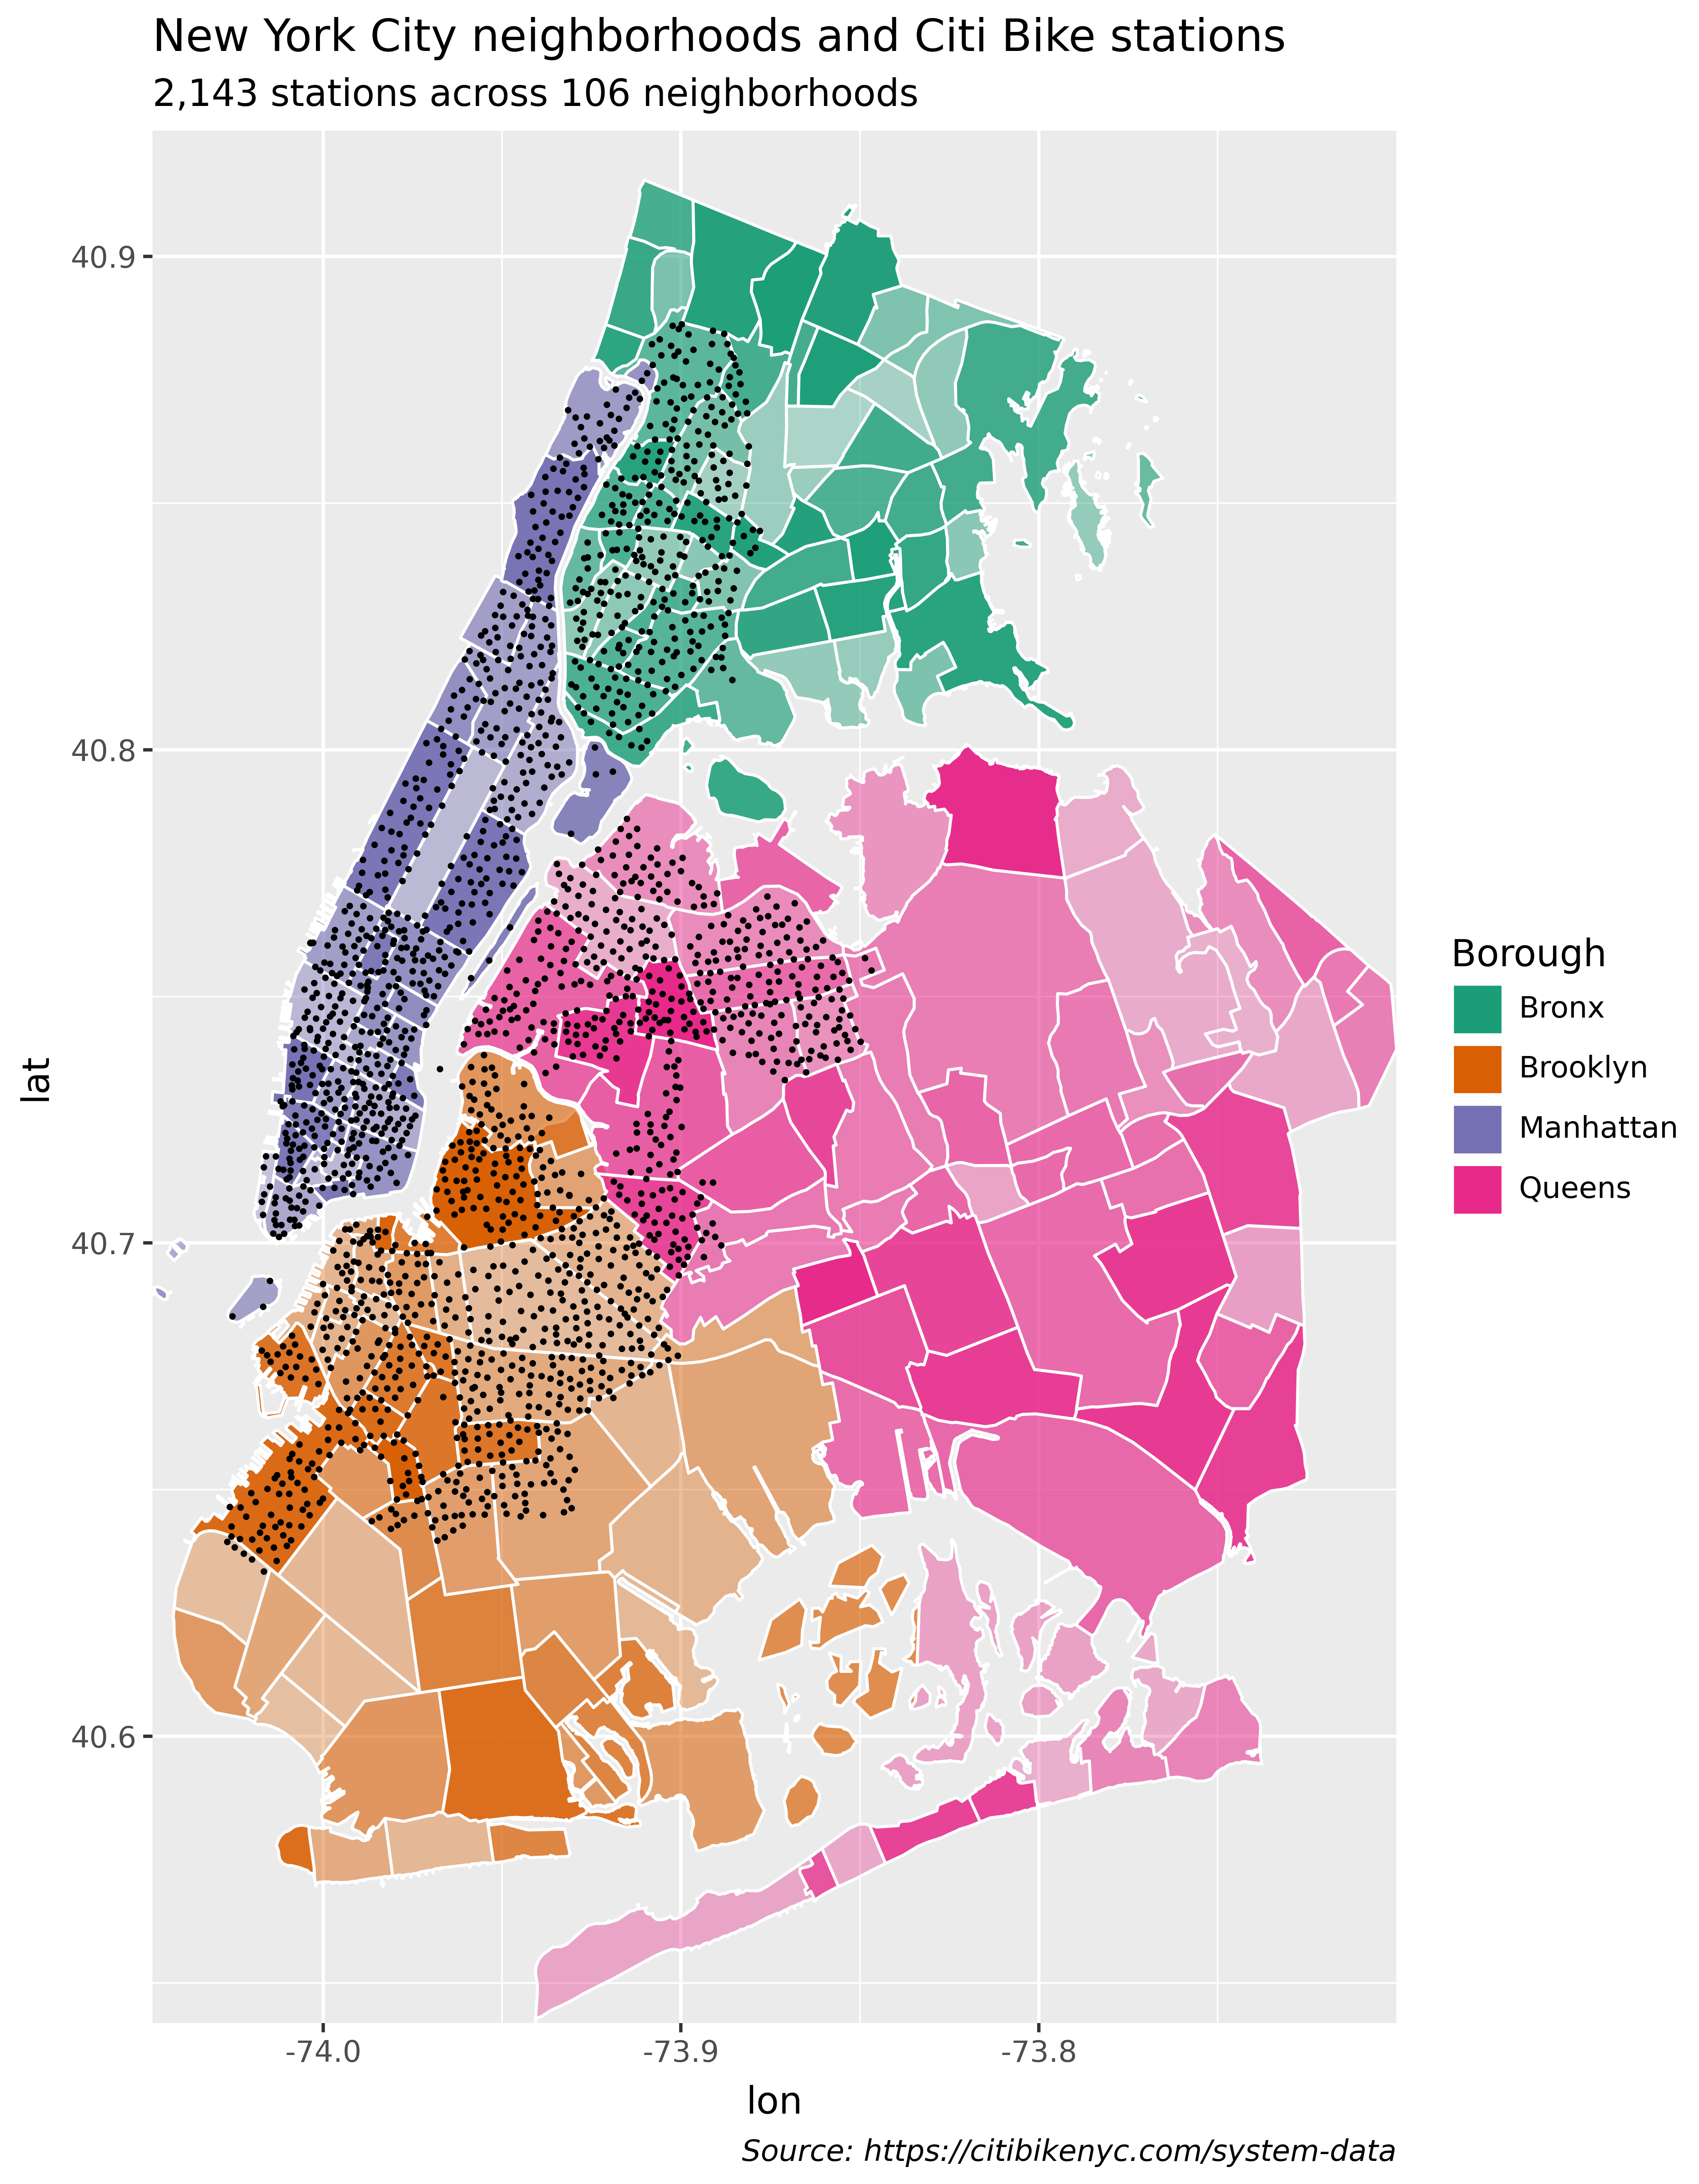

In [14]:
(
    plotnine.ggplot(neighborhoods_coords, plotnine.aes(x='lon', y='lat', group='id'))
    + plotnine.geom_polygon(plotnine.aes(alpha='neighborhood', fill='borough'), color='white')
    + plotnine.geom_point(stations, size=0.1)
    + plotnine.scale_x_continuous(expand=(0, 0))
    + plotnine.scale_y_continuous(expand=(0, 0, 0, 0.01))
    + plotnine.scale_alpha_ordinal(range=(0.3, 1))
    + plotnine.scale_fill_brewer(type='qual', palette=2)
    + plotnine.guides(alpha=False)
    + plotnine.labs(
        title='New York City neighborhoods and Citi Bike stations',
        subtitle='2,143 stations across 106 neighborhoods',
        caption='Source: https://citibikenyc.com/system-data',
        fill='Borough')
    #+plotnine.theme_void(base_family='Guardian Sans', base_size=14)
    + plotnine.theme(
        dpi=300,
        figure_size=(7, 9),
        plot_background=plotnine.element_rect(fill='white', color='white'),
        plot_caption=plotnine.element_text(style='italic'),
        plot_margin=0.01,
        plot_title=plotnine.element_text(ha='left'))
)

In [17]:
trips = (
    trips
        .select(
            bike_type=pl.col('rideable_type')
                .str.split('_')
                .list.get(0)
                .cast(pl.Categorical),
            rider_type=pl.col('member_casual')
                .cast(pl.Categorical),
            datetime_start=pl.col('started_at'),
            datetime_end=pl.col('ended_at'),
            station_start=pl.col('start_station_name'),
            station_end=pl.col('end_station_name'),
            lon_start=pl.col('start_lng'),
            lat_start=pl.col('start_lat'),
            lon_end=pl.col('end_lng'),
            lat_end=pl.col('end_lat'))
        .with_columns(
            duration=(pl.col('datetime_end') - pl.col('datetime_start')))
); trips.columns

['bike_type',
 'rider_type',
 'datetime_start',
 'datetime_end',
 'station_start',
 'station_end',
 'lon_start',
 'lat_start',
 'lon_end',
 'lat_end',
 'duration']

In [20]:
trips = (
    trips
        .drop_nulls()
        .filter(
            (pl.col('datetime_start') >= pl.date(2024, 3, 1)) &
            (pl.col('datetime_end') < pl.date(2024, 4, 1)))
        .filter(
            ~(
                (pl.col('station_start') == pl.col('station_end')) &
                (pl.col('duration').dt.total_seconds() < 5 * 60)))
); trips.height

2639170

**Add trip distance**...

## Getting started

In [2]:
# pc
pl.show_versions()

--------Version info---------
Polars:              1.27.1
Index type:          UInt32
Platform:            Windows-10-10.0.19045-SP0
Python:              3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]
LTS CPU:             False

----Optional dependencies----
Azure CLI            <not installed>
adbc_driver_manager  <not installed>
altair               <not installed>
azure.identity       <not installed>
boto3                <not installed>
cloudpickle          <not installed>
connectorx           <not installed>
deltalake            <not installed>
fastexcel            <not installed>
fsspec               <not installed>
gevent               <not installed>
google.auth          <not installed>
great_tables         <not installed>
matplotlib           3.10.1
numpy                2.2.4
openpyxl             3.1.5
pandas               2.2.3
polars_cloud         <not installed>
pyarrow              19.0.1
pydantic             2.11.3
pyiceberg            <no

In [5]:
# linux
pl.show_versions()

--------Version info---------
Polars:              1.29.0
Index type:          UInt32
Platform:            Linux-6.14.5-arch1-1-x86_64-with-glibc2.41
Python:              3.13.3 (main, Apr  9 2025, 07:44:25) [GCC 14.2.1 20250207]
LTS CPU:             False

----Optional dependencies----
Azure CLI            <not installed>
adbc_driver_manager  1.6.0
altair               5.5.0
azure.identity       <not installed>
boto3                <not installed>
cloudpickle          3.1.1
connectorx           0.4.3
deltalake            0.25.5
fastexcel            0.14.0
fsspec               2025.3.2
gevent               25.4.2
google.auth          <not installed>
great_tables         0.17.0
matplotlib           3.10.1
numpy                2.2.5
openpyxl             3.1.5
pandas               2.2.3
polars_cloud         <not installed>
pyarrow              20.0.0
pydantic             2.11.4
pyiceberg            0.9.1
sqlalchemy           2.0.40
torch                <not installed>
xlsx2csv            

In [3]:
pl.Config.state()

{'POLARS_AUTO_STRUCTIFY': None,
 'POLARS_ENGINE_AFFINITY': None,
 'POLARS_FMT_MAX_COLS': None,
 'POLARS_FMT_MAX_ROWS': None,
 'POLARS_FMT_NUM_DECIMAL': None,
 'POLARS_FMT_NUM_GROUP_SEPARATOR': None,
 'POLARS_FMT_NUM_LEN': None,
 'POLARS_FMT_STR_LEN': None,
 'POLARS_FMT_TABLE_CELL_ALIGNMENT': None,
 'POLARS_FMT_TABLE_CELL_LIST_LEN': None,
 'POLARS_FMT_TABLE_CELL_NUMERIC_ALIGNMENT': None,
 'POLARS_FMT_TABLE_DATAFRAME_SHAPE_BELOW': None,
 'POLARS_FMT_TABLE_FORMATTING': None,
 'POLARS_FMT_TABLE_HIDE_COLUMN_DATA_TYPES': None,
 'POLARS_FMT_TABLE_HIDE_COLUMN_NAMES': None,
 'POLARS_FMT_TABLE_HIDE_COLUMN_SEPARATOR': None,
 'POLARS_FMT_TABLE_HIDE_DATAFRAME_SHAPE_INFORMATION': None,
 'POLARS_FMT_TABLE_INLINE_COLUMN_DATA_TYPE': None,
 'POLARS_FMT_TABLE_ROUNDED_CORNERS': None,
 'POLARS_MAX_EXPR_DEPTH': None,
 'POLARS_STREAMING_CHUNK_SIZE': None,
 'POLARS_TABLE_WIDTH': None,
 'POLARS_VERBOSE': None,
 'POLARS_WARN_UNSTABLE': None,
 'set_fmt_float': 'mixed',
 'set_float_precision': None,
 'set_thousan

In [6]:
with pl.Config() as cfg:
    cfg.set_verbose(True)
    # Polars operation for which you want to see the verbose logging
# Code outside of the scope is not affected

with pl.Config(verbose=True):
    # Polars operation you want to see the verbose logging of
    pass

In [7]:
def generate_random_string(length: int) -> str:
    return ''.join(random.choice(string.ascii_letters) for i in range(length))

data = dict()
for i in range(1, 11):
    data[f'column_{i}'] = [generate_random_string(50) for _ in range(5)]

df = pl.DataFrame(data); df

column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10
str,str,str,str,str,str,str,str,str,str
"""JVEccTHCydLGBaOXQNeuGRXdeRmwcz…","""lPXepmyqNPDHltboppvrafcWABQBHr…","""zuoBnHSBLUfgNczdxIlKkOMSeQOHSA…","""taTHxwexNfMNspUFZDDgsHlpQTwmVF…","""AyQKGUrgwdeBHcSHMXljhaRqGIpGJP…","""AxrQuPdkifkHehPlXikEfAxFQkBxIV…","""GpgyIUJosPWzvZZkMyfeCSoBVkrkvm…","""dFoEaMCvfbKacSlTSLjjdTywBCJDzl…","""OqcXScyhDYtXauxjbELynyBhEPGsoJ…","""FcASVXrCYCqGfHahmpqEOyiOIgnYTD…"
"""bUqBHiKQdAVZjTtgYrVYaPMAELqjqC…","""AECMwVDTXAFpnjRoNAqTsPYEjIjIGu…","""gOyvPmuXmUqTSPuWwZOzPSoyGhEXeH…","""BSkxHHtHYQmdbujsaNEYakTNPjzZdm…","""FdUbKOKlptwFNXUTWbMXuBoxHuXWUE…","""oARNHdfluGfvufmxqKnHMFKOzMmoJD…","""JIaBdknsNLVSdensjKqZSfzBElepcF…","""nZuwgbuGyPCLjRxkDDVScCoxXtlSaL…","""ynhueXNQxcAtiPCIzxFQbvtNsFWPhP…","""wVAFynNdnHaxhqDsmqYuHvEagFjdwP…"
"""rYCOmEUyYKPasYjNLKnKPACBgBbvzm…","""mKVViJNGVrxMasTBxfcNTuuzgRbrEZ…","""nAEqWjXVpVHYmjEGGzilLCObUdjrbF…","""IlMAytqCZnVADzQYhdhiHofhChJBGf…","""XGaiPXuLykWxzliruLihXkqYtPiCaY…","""YOBbEOBlkFZwvKTBoqwnjIaSkAHmRs…","""ZsFHyDbGNxsonKxBZrRZZVpDzAapih…","""CFIHuEdbQTaVNVlYpwygYfuhuefgll…","""aSUCnRMPcZEBQzcdydStmLsefTpRpe…","""HstZiZowtQkpIUNyFlJgzYlPeSROZr…"
"""WSKfOxLNJUQJUyAdBhcbFSZoVVyxxg…","""iJAYRJVwEDQJJimRUVBNphWwfJnXnJ…","""jrmbdHSYAankBsylLJJoQfWXrpIJih…","""bNAUTmeBgVzGFBGJdySRfhhJhamNwh…","""yFuLSQQKTDnKECpZHmbUJoODMvKhPk…","""vYEnjFzmAkOTwOmIfehaaKSNfkUujl…","""bGetAGRDcQYKIJbASFBbKlzBdBEoSA…","""XqzmHAEtLQdmDlnzdXVtXIpopJrkDv…","""ONYsbfbFHwCCddIQnrodKJMSxrhJZP…","""jCLuhbtoYvIxWkLEyvPfDLareXBNmR…"
"""DczCrXjxEeIHYRPmkquYvtHedbwcyl…","""ZGrmxBMDkqauGjOaVislUWGIJvcUke…","""rRvFeydPKHDCwHneByTIFrdWFGUPNa…","""qvVZIHSseOdRGQdRfIAaCssbPXUJyo…","""xqVxcsTHBtmuRuABeOdCxESOaPCgEU…","""vlShoJUaMOjwjkBPUGiAkIUmJhARhM…","""YAINqWeQhvjpMhzfxHYDKFMkUhTJcG…","""coPCORFXmwXyOxmjvTrEAuIiEiLbJH…","""eHoJioDdtwEOWbrLbfGZLTCQcrCuvn…","""FKdNVESjHifHDMBABfZKkMXaaJjwCn…"


In [8]:
with pl.Config(tbl_cols=-1, fmt_str_lengths=4):
    print(df)

shape: (5, 10)
┌───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ colu… ┆ colu… ┆ colu… ┆ colu… ┆ colu… ┆ colu… ┆ colu… ┆ colu… ┆ colu… ┆ colu… │
│ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ str   ┆ str   ┆ str   ┆ str   ┆ str   ┆ str   ┆ str   ┆ str   ┆ str   ┆ str   │
╞═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ JVEc… ┆ lPXe… ┆ zuoB… ┆ taTH… ┆ AyQK… ┆ AxrQ… ┆ Gpgy… ┆ dFoE… ┆ OqcX… ┆ FcAS… │
│ bUqB… ┆ AECM… ┆ gOyv… ┆ BSkx… ┆ FdUb… ┆ oARN… ┆ JIaB… ┆ nZuw… ┆ ynhu… ┆ wVAF… │
│ rYCO… ┆ mKVV… ┆ nAEq… ┆ IlMA… ┆ XGai… ┆ YOBb… ┆ ZsFH… ┆ CFIH… ┆ aSUC… ┆ HstZ… │
│ WSKf… ┆ iJAY… ┆ jrmb… ┆ bNAU… ┆ yFuL… ┆ vYEn… ┆ bGet… ┆ Xqzm… ┆ ONYs… ┆ jCLu… │
│ DczC… ┆ ZGrm… ┆ rRvF… ┆ qvVZ… ┆ xqVx… ┆ vlSh… ┆ YAIN… ┆ coPC… ┆ eHoJ… ┆ FKdN… │
└───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┘


In [9]:
class YourContextManager:
    def __enter__(self):
        print('Entering context')
    def __exit__(self, type, value, traceback):
        print('Exiting context')

with YourContextManager():
    print('Your code')

Entering context
Your code
Exiting context


In [10]:
@pl.Config(ascii_tables=True)
def write_ascii_frame_to_stdout(df: pl.DataFrame) -> None:
    print(str(df))

In [11]:
@pl.Config(verbose=True)
def function_that_im_debugging(df: pl.DataFrame) -> None:
    # Polars operation for which you want to see the verbose logging
    pass

In [12]:
write_ascii_frame_to_stdout(df)

shape: (5, 10)
+-----------+-----------+-----------+-----------+-----+-----------+----------+----------+----------+
| column_1  | column_2  | column_3  | column_4  | ... | column_7  | column_8 | column_9 | column_1 |
| ---       | ---       | ---       | ---       |     | ---       | ---      | ---      | 0        |
| str       | str       | str       | str       |     | str       | str      | str      | ---      |
|           |           |           |           |     |           |          |          | str      |
+==================================================================================================+
| JVEccTHCy | lPXepmyqN | zuoBnHSBL | taTHxwexN | ... | GpgyIUJos | dFoEaMCv | OqcXScyh | FcASVXrC |
| dLGBaOXQN | PDHltbopp | UfgNczdxI | fMNspUFZD |     | PWzvZZkMy | fbKacSlT | DYtXauxj | YCqGfHah |
| euGRXdeRm | vrafcWABQ | lKkOMSeQO | DgsHlpQTw |     | feCSoBVkr | SLjjdTyw | bELynyBh | mpqEOyiO |
| wcz...    | BHr...    | HSA...    | mVF...    |     | kvm...    | BCJDzl..

## Moving from pandas to Polars

In [16]:
!cat data/animals.csv

animal,class,habitat,diet,lifespan,status,features,weight
dolphin,mammal,oceans/rivers,carnivore,40,least concern,high intelligence,150
duck,bird,wetlands,omnivore,8,least concern,waterproof feathers,3
elephant,mammal,savannah,herbivore,60,endangered,large ears and trunk,8000
ibis,bird,wetlands,omnivore,16,least concern,"long, curved bill",1
impala,mammal,savannah,herbivore,12,least concern,"long, curved horns",70
kudu,mammal,savannah,herbivore,15,least concern,spiral horns,250
narwhal,mammal,arctic ocean,carnivore,40,near threatened,"long, spiral tusk",
panda,mammal,forests,herbivore,20,vulnerable,black and white coloration,100
polar bear,mammal,arctic,carnivore,25,vulnerable,thick fur and blubber,720
ray,fish,oceans,carnivore,20,"","flat, disc-shaped body",90


In [37]:
animals_pd = pd.read_csv('data/animals.csv', sep=',', header=0)
animals_pl = pl.read_csv('data/animals.csv', separator=',', has_header=True)

print(f'{type(animals_pd) = }')
print(f'{type(animals_pl) = }')

type(animals_pd) = <class 'pandas.core.frame.DataFrame'>
type(animals_pl) = <class 'polars.dataframe.frame.DataFrame'>


In [38]:
animals_pd

,animal,class,habitat,diet,lifespan,status,features,weight
0,dolphin,mammal,oceans/rivers,carnivore,40,least concern,high intelligence,150.0
1,duck,bird,wetlands,omnivore,8,least concern,waterproof feathers,3.0
2,elephant,mammal,savannah,herbivore,60,endangered,large ears and trunk,8000.0
3,ibis,bird,wetlands,omnivore,16,least concern,"long, curved bill",1.0
4,impala,mammal,savannah,herbivore,12,least concern,"long, curved horns",70.0
5,kudu,mammal,savannah,herbivore,15,least concern,spiral horns,250.0
6,narwhal,mammal,arctic ocean,carnivore,40,near threatened,"long, spiral tusk",NaN
7,panda,mammal,forests,herbivore,20,vulnerable,black and white coloration,100.0
8,polar bear,mammal,arctic,carnivore,25,vulnerable,thick fur and blubber,720.0
9,ray,fish,oceans,carnivore,20,NaN,"flat, disc-shaped body",90.0


In [39]:
animals_pl

animal,class,habitat,diet,lifespan,status,features,weight
str,str,str,str,i64,str,str,i64
"""dolphin""","""mammal""","""oceans/rivers""","""carnivore""",40,"""least concern""","""high intelligence""",150
"""duck""","""bird""","""wetlands""","""omnivore""",8,"""least concern""","""waterproof feathers""",3
"""elephant""","""mammal""","""savannah""","""herbivore""",60,"""endangered""","""large ears and trunk""",8000
"""ibis""","""bird""","""wetlands""","""omnivore""",16,"""least concern""","""long, curved bill""",1
"""impala""","""mammal""","""savannah""","""herbivore""",12,"""least concern""","""long, curved horns""",70
"""kudu""","""mammal""","""savannah""","""herbivore""",15,"""least concern""","""spiral horns""",250
"""narwhal""","""mammal""","""arctic ocean""","""carnivore""",40,"""near threatened""","""long, spiral tusk""",null
"""panda""","""mammal""","""forests""","""herbivore""",20,"""vulnerable""","""black and white coloration""",100
"""polar bear""","""mammal""","""arctic""","""carnivore""",25,"""vulnerable""","""thick fur and blubber""",720


In [40]:
animals_pd['animal']

0       dolphin
1          duck
2      elephant
3          ibis
4        impala
5          kudu
6       narwhal
7         panda
8    polar bear
9           ray
Name: animal, dtype: object

In [41]:
animals_pl.get_column('animal')

animal
str
"""dolphin"""
"""duck"""
"""elephant"""
"""ibis"""
"""impala"""
"""kudu"""
"""narwhal"""
"""panda"""
"""polar bear"""


In [42]:
animals_pd.drop(columns=['habitat', 'diet', 'features'], inplace=True)

In [43]:
animals_pd

,animal,class,lifespan,status,weight
0,dolphin,mammal,40,least concern,150.0
1,duck,bird,8,least concern,3.0
2,elephant,mammal,60,endangered,8000.0
3,ibis,bird,16,least concern,1.0
4,impala,mammal,12,least concern,70.0
5,kudu,mammal,15,least concern,250.0
6,narwhal,mammal,40,near threatened,NaN
7,panda,mammal,20,vulnerable,100.0
8,polar bear,mammal,25,vulnerable,720.0
9,ray,fish,20,NaN,90.0


In [45]:
animals_pl = animals_pl.drop('habitat', 'diet', 'features')

In [46]:
animals_pl

animal,class,lifespan,status,weight
str,str,i64,str,i64
"""dolphin""","""mammal""",40,"""least concern""",150
"""duck""","""bird""",8,"""least concern""",3
"""elephant""","""mammal""",60,"""endangered""",8000
"""ibis""","""bird""",16,"""least concern""",1
"""impala""","""mammal""",12,"""least concern""",70
"""kudu""","""mammal""",15,"""least concern""",250
"""narwhal""","""mammal""",40,"""near threatened""",null
"""panda""","""mammal""",20,"""vulnerable""",100
"""polar bear""","""mammal""",25,"""vulnerable""",720


In [47]:
animals_pd.index

RangeIndex(start=0, stop=10, step=1)

In [48]:
animals_agg_pd = animals_pd.groupby(['class', 'status'])[['weight']].mean(); animals_agg_pd

weight
class  status                      
bird   least concern       2.000000
mammal endangered       8000.000000
       least concern     156.666667
       near threatened          NaN
       vulnerable        410.000000

In [49]:
animals_agg_pd.index

MultiIndex([(  'bird',   'least concern'),
            ('mammal',      'endangered'),
            ('mammal',   'least concern'),
            ('mammal', 'near threatened'),
            ('mammal',      'vulnerable')],
           names=['class', 'status'])

In [50]:
animals_pl.group_by(['class', 'status']).agg(pl.col('weight').mean())

class,status,weight
str,str,f64
"""mammal""","""near threatened""",null
"""mammal""","""least concern""",156.666667
"""bird""","""least concern""",2.0
"""mammal""","""endangered""",8000.0
"""fish""","""""",90.0
"""mammal""","""vulnerable""",410.0


In [51]:
animals_pd.drop('weight', axis=1)

,animal,class,lifespan,status
0,dolphin,mammal,40,least concern
1,duck,bird,8,least concern
2,elephant,mammal,60,endangered
3,ibis,bird,16,least concern
4,impala,mammal,12,least concern
5,kudu,mammal,15,least concern
6,narwhal,mammal,40,near threatened
7,panda,mammal,20,vulnerable
8,polar bear,mammal,25,vulnerable
9,ray,fish,20,NaN


In [52]:
animals_pl.drop('weight')

animal,class,lifespan,status
str,str,i64,str
"""dolphin""","""mammal""",40,"""least concern"""
"""duck""","""bird""",8,"""least concern"""
"""elephant""","""mammal""",60,"""endangered"""
"""ibis""","""bird""",16,"""least concern"""
"""impala""","""mammal""",12,"""least concern"""
"""kudu""","""mammal""",15,"""least concern"""
"""narwhal""","""mammal""",40,"""near threatened"""
"""panda""","""mammal""",20,"""vulnerable"""
"""polar bear""","""mammal""",25,"""vulnerable"""


In [54]:
animals_pd[['animal', 'class']]

,animal,class
0,dolphin,mammal
1,duck,bird
2,elephant,mammal
3,ibis,bird
4,impala,mammal
5,kudu,mammal
6,narwhal,mammal
7,panda,mammal
8,polar bear,mammal
9,ray,fish


In [55]:
animals_pd[animals_pd['status'] == 'endangered']

,animal,class,lifespan,status,weight
2,elephant,mammal,60,endangered,8000.0


In [56]:
animals_pd[:3]

,animal,class,lifespan,status,weight
0,dolphin,mammal,40,least concern,150.0
1,duck,bird,8,least concern,3.0
2,elephant,mammal,60,endangered,8000.0


In [57]:
animals_pd['weight'] = animals_pd['weight'] * 1000

In [58]:
animals_pd['weight']

0     150000.0
1       3000.0
2    8000000.0
3       1000.0
4      70000.0
5     250000.0
6          NaN
7     100000.0
8     720000.0
9      90000.0
Name: weight, dtype: float64

In [59]:
animals_pd['weight'] = animals_pd['weight'].sort_values()

In [61]:
animals_pd['weight']

0     150000.0
1       3000.0
2    8000000.0
3       1000.0
4      70000.0
5     250000.0
6          NaN
7     100000.0
8     720000.0
9      90000.0
Name: weight, dtype: float64

In [62]:
lazy_query = (
    pl
        .scan_csv('data/animals.csv')
        .group_by('class')
        .agg(pl.col('weight').mean())
        .filter(pl.col('class') == 'mammal')
)

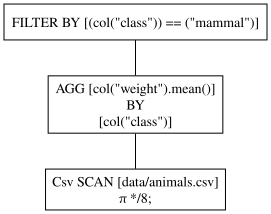

In [63]:
lazy_query.show_graph(optimized=False)

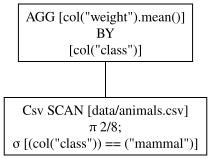

In [64]:
lazy_query.show_graph(optimized=True)

In [65]:
lazy_query.collect()

class,weight
str,f64
"""mammal""",1548.333333


In [66]:
animals_pd.drop_duplicates(subset='class')

,animal,class,lifespan,status,weight
0,dolphin,mammal,40,least concern,150000.0
1,duck,bird,8,least concern,3000.0
9,ray,fish,20,NaN,90000.0


In [67]:
animals_pl.unique(subset='class')

animal,class,lifespan,status,weight
str,str,i64,str,i64
"""dolphin""","""mammal""",40,"""least concern""",150
"""duck""","""bird""",8,"""least concern""",3
"""ray""","""fish""",20,"""""",90


In [69]:
animals_pl.unique(subset='class', maintain_order=False)

animal,class,lifespan,status,weight
str,str,i64,str,i64
"""duck""","""bird""",8,"""least concern""",3
"""dolphin""","""mammal""",40,"""least concern""",150
"""ray""","""fish""",20,"""""",90


In [70]:
animals_pd.dropna(subset='weight')

,animal,class,lifespan,status,weight
0,dolphin,mammal,40,least concern,150000.0
1,duck,bird,8,least concern,3000.0
2,elephant,mammal,60,endangered,8000000.0
3,ibis,bird,16,least concern,1000.0
4,impala,mammal,12,least concern,70000.0
5,kudu,mammal,15,least concern,250000.0
7,panda,mammal,20,vulnerable,100000.0
8,polar bear,mammal,25,vulnerable,720000.0
9,ray,fish,20,NaN,90000.0


In [71]:
animals_pl.drop_nulls(subset='weight')

animal,class,lifespan,status,weight
str,str,i64,str,i64
"""dolphin""","""mammal""",40,"""least concern""",150
"""duck""","""bird""",8,"""least concern""",3
"""elephant""","""mammal""",60,"""endangered""",8000
"""ibis""","""bird""",16,"""least concern""",1
"""impala""","""mammal""",12,"""least concern""",70
"""kudu""","""mammal""",15,"""least concern""",250
"""panda""","""mammal""",20,"""vulnerable""",100
"""polar bear""","""mammal""",25,"""vulnerable""",720
"""ray""","""fish""",20,"""""",90


In [73]:
animals_pd.sort_values('weight', ascending=False)

,animal,class,lifespan,status,weight
2,elephant,mammal,60,endangered,8000000.0
8,polar bear,mammal,25,vulnerable,720000.0
5,kudu,mammal,15,least concern,250000.0
0,dolphin,mammal,40,least concern,150000.0
7,panda,mammal,20,vulnerable,100000.0
9,ray,fish,20,NaN,90000.0
4,impala,mammal,12,least concern,70000.0
1,duck,bird,8,least concern,3000.0
3,ibis,bird,16,least concern,1000.0
6,narwhal,mammal,40,near threatened,NaN


In [74]:
animals_pl.sort('weight', descending=True)

animal,class,lifespan,status,weight
str,str,i64,str,i64
"""narwhal""","""mammal""",40,"""near threatened""",null
"""elephant""","""mammal""",60,"""endangered""",8000
"""polar bear""","""mammal""",25,"""vulnerable""",720
"""kudu""","""mammal""",15,"""least concern""",250
"""dolphin""","""mammal""",40,"""least concern""",150
"""panda""","""mammal""",20,"""vulnerable""",100
"""ray""","""fish""",20,"""""",90
"""impala""","""mammal""",12,"""least concern""",70
"""duck""","""bird""",8,"""least concern""",3


In [76]:
animals_pd.assign(lifespan=animals_pd['lifespan'].astype(float))

,animal,class,lifespan,status,weight
0,dolphin,mammal,40.0,least concern,150000.0
1,duck,bird,8.0,least concern,3000.0
2,elephant,mammal,60.0,endangered,8000000.0
3,ibis,bird,16.0,least concern,1000.0
4,impala,mammal,12.0,least concern,70000.0
5,kudu,mammal,15.0,least concern,250000.0
6,narwhal,mammal,40.0,near threatened,NaN
7,panda,mammal,20.0,vulnerable,100000.0
8,polar bear,mammal,25.0,vulnerable,720000.0
9,ray,fish,20.0,NaN,90000.0


In [77]:
animals_pl.with_columns(pl.col('lifespan').cast(pl.Float64))

animal,class,lifespan,status,weight
str,str,f64,str,i64
"""dolphin""","""mammal""",40.0,"""least concern""",150
"""duck""","""bird""",8.0,"""least concern""",3
"""elephant""","""mammal""",60.0,"""endangered""",8000
"""ibis""","""bird""",16.0,"""least concern""",1
"""impala""","""mammal""",12.0,"""least concern""",70
"""kudu""","""mammal""",15.0,"""least concern""",250
"""narwhal""","""mammal""",40.0,"""near threatened""",null
"""panda""","""mammal""",20.0,"""vulnerable""",100
"""polar bear""","""mammal""",25.0,"""vulnerable""",720


In [78]:
animals_pd.groupby(["class", "status"])[["weight"]].mean()

weight
class  status                       
bird   least concern    2.000000e+03
mammal endangered       8.000000e+06
       least concern    1.566667e+05
       near threatened           NaN
       vulnerable       4.100000e+05

In [79]:
animals_pl.group_by("class", "status").agg(pl.col("weight").mean())

class,status,weight
str,str,f64
"""mammal""","""endangered""",8000.0
"""mammal""","""near threatened""",null
"""mammal""","""vulnerable""",410.0
"""fish""","""""",90.0
"""bird""","""least concern""",2.0
"""mammal""","""least concern""",156.666667


In [80]:
animals_pl = pl.DataFrame(animals_pd); animals_pl

animal,class,lifespan,status,weight
str,str,i64,str,f64
"""dolphin""","""mammal""",40,"""least concern""",150000.0
"""duck""","""bird""",8,"""least concern""",3000.0
"""elephant""","""mammal""",60,"""endangered""",8e6
"""ibis""","""bird""",16,"""least concern""",1000.0
"""impala""","""mammal""",12,"""least concern""",70000.0
"""kudu""","""mammal""",15,"""least concern""",250000.0
"""narwhal""","""mammal""",40,"""near threatened""",null
"""panda""","""mammal""",20,"""vulnerable""",100000.0
"""polar bear""","""mammal""",25,"""vulnerable""",720000.0


In [81]:
there_and_back_again_df = animals_pl.to_pandas(); there_and_back_again_df

,animal,class,lifespan,status,weight
0,dolphin,mammal,40,least concern,150000.0
1,duck,bird,8,least concern,3000.0
2,elephant,mammal,60,endangered,8000000.0
3,ibis,bird,16,least concern,1000.0
4,impala,mammal,12,least concern,70000.0
5,kudu,mammal,15,least concern,250000.0
6,narwhal,mammal,40,near threatened,NaN
7,panda,mammal,20,vulnerable,100000.0
8,polar bear,mammal,25,vulnerable,720000.0
9,ray,fish,20,None,90000.0


# Form

## Data Structures and Data Types

In [84]:
sales_series = pl.Series('sales', [105., 300., 250])

In [85]:
sales_series

sales
f64
105.0
300.0
250.0


In [99]:
pl.Series('sales', [[105., 5.], [300.], [250]])

sales
list[f64]
"[105.0, 5.0]"
[300.0]
[250.0]


In [86]:
sales_df = pl.DataFrame(
    {
        'sales': sales_series,
        'customer_id': [24, 25, 26],
    }
); sales_df

sales,customer_id
f64,i64
105.0,24
300.0,25
250.0,26


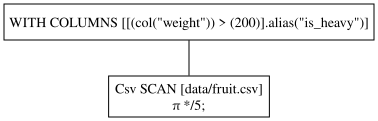

In [87]:
lazy_df = pl.scan_csv('data/fruit.csv').with_columns(
    is_heavy=pl.col('weight') > 200
); lazy_df.show_graph()

In [94]:
coordinates = pl.DataFrame(
    [
        pl.Series('point_2d', [[1, 3], [2, 5]]),
        pl.Series('point_3d', [[1, 7, 3], [8, 1, 0]]),
    ],
    schema={
        'point_2d': pl.Array(shape=2, inner=pl.Int64),
        'point_3d': pl.Array(shape=3, inner=pl.Int64),
    },
); coordinates

point_2d,point_3d
"array[i64, 2]","array[i64, 3]"
"[1, 3]","[1, 7, 3]"
"[2, 5]","[8, 1, 0]"


In [92]:
weather_readings = pl.DataFrame(
    {
        'temperature': [[72.5, 75., 77.3], [68., 70.2]],
        'wind_speed': [[15, 20], [10, 12, 14, 16]],
    }
); weather_readings

temperature,wind_speed
list[f64],list[i64]
"[72.5, 75.0, 77.3]","[15, 20]"
"[68.0, 70.2]","[10, 12, … 16]"


In [95]:
rating_series = pl.Series(
    'ratings',
    [
        {'Movie': 'Cars', 'Theatre': 'NE', 'Avg_rating': 4.5},
        {'Movie': 'Toy Story', 'Theatre': 'ME', 'Avg_Rating': 4.9},
    ],
); rating_series

ratings
struct[3]
"{""Cars"",""NE"",4.5}"
"{""Toy Story"",""ME"",null}"


In [100]:
missing_df = pl.DataFrame(
    {
        'value' : [None, 2, 3, 4, None, None, 7, 8, 9, None]
    },
); missing_df

value
i64
null
2
3
4
null
null
7
8
9


In [101]:
missing_df.with_columns(
    filled_with_single=pl.col('value').fill_null(-1))

value,filled_with_single
i64,i64
null,-1
2,2
3,3
4,4
null,-1
null,-1
7,7
8,8
9,9


In [103]:
missing_df.with_columns(
    forward=pl.col('value').fill_null(strategy='forward'),
    backward=pl.col('value').fill_null(strategy='backward'),
    min=pl.col('value').fill_null(strategy='min'),
    max=pl.col('value').fill_null(strategy='max'),
    mean=pl.col('value').fill_null(strategy='mean'),
    zero=pl.col('value').fill_null(strategy='zero'),
    one=pl.col('value').fill_null(strategy='one'),
)

value,forward,backward,min,max,mean,zero,one
i64,i64,i64,i64,i64,i64,i64,i64
null,null,2,2,9,5,0,1
2,2,2,2,2,2,2,2
3,3,3,3,3,3,3,3
4,4,4,4,4,4,4,4
null,4,7,2,9,5,0,1
null,4,7,2,9,5,0,1
7,7,7,7,7,7,7,7
8,8,8,8,8,8,8,8
9,9,9,9,9,9,9,9


In [104]:
missing_df.with_columns(
    expression_mean=pl.col('value').fill_null(pl.col('value').mean()
                                             )
)

value,expression_mean
i64,f64
null,5.5
2,2.0
3,3.0
4,4.0
null,5.5
null,5.5
7,7.0
8,8.0
9,9.0


In [105]:
missing_df.interpolate()

value
f64
null
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0


In [113]:
string_df = pl.DataFrame(
    dict(id=['10000', '20000', '30000'])
);string_df

id
str
"""10000"""
"""20000"""
"""30000"""


In [114]:
f'Estimated size: {string_df.estimated_size('b')} bytes'

'Estimated size: 15 bytes'

In [115]:
int_df = string_df.select(pl.col('id').cast(pl.UInt16)); int_df

id
u16
10000
20000
30000


In [116]:
f'Estimated size: {int_df.estimated_size('b')} bytes'

'Estimated size: 6 bytes'

In [117]:
data_types_df = pl.DataFrame(
    dict(
        id=[10000, 20000, 30000],
        value=[1., 2., 3.],
        value2=['1', '2', '3'])
); data_types_df.cast(pl.UInt16)

id,value,value2
u16,u16,u16
10000,1,1
20000,2,2
30000,3,3


In [118]:
data_types_df.cast(
    dict(
        id=pl.UInt16,
        value=pl.Float32,
        value2=pl.UInt8)
)

id,value,value2
u16,f32,u8
10000,1.0,1
20000,2.0,2
30000,3.0,3


In [121]:
data_types_df.cast(
    {
        pl.Float64: pl.Float32,
        pl.String: pl.UInt8}
)

id,value,value2
i64,f32,u8
10000,1.0,1
20000,2.0,2
30000,3.0,3


In [122]:
data_types_df.cast({pl.selectors.numeric(): pl.UInt16})

id,value,value2
u16,u16,str
10000,1,"""1"""
20000,2,"""2"""
30000,3,"""3"""


## Eager and Lazy APIs

## Eager API: DataFrame

In [ ]:
%%time
trips = pl.read_parquet('data/taxi/yellow_tripdata_*.parquet')

sum_per_vendor = trips.group_by('VendorID').sum()
income_per_distance_per_vendor = sum_per_vendor.select(
    'VendorID',
    income_per_distance=pl.col('total_amount') / pl.col('trip_distance'),)

top_three = income_per_distance_per_vendor.sort(
    by='income_per_distance', descending=True).head(3); top_three

CPU times: total: 33.8 s
Wall time: 2.94 s


VendorID,income_per_distance
i64,f64
1,6.434789
6,5.296493
5,4.731557


In [3]:
trips

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
i64,datetime[ns],datetime[ns],f64,f64,f64,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,2022-01-01 00:35:40,2022-01-01 00:53:29,2.0,3.8,1.0,"""N""",142,236,1,14.5,3.0,0.5,3.65,0.0,0.3,21.95,2.5,0.0
1,2022-01-01 00:33:43,2022-01-01 00:42:07,1.0,2.1,1.0,"""N""",236,42,1,8.0,0.5,0.5,4.0,0.0,0.3,13.3,0.0,0.0
2,2022-01-01 00:53:21,2022-01-01 01:02:19,1.0,0.97,1.0,"""N""",166,166,1,7.5,0.5,0.5,1.76,0.0,0.3,10.56,0.0,0.0
2,2022-01-01 00:25:21,2022-01-01 00:35:23,1.0,1.09,1.0,"""N""",114,68,2,8.0,0.5,0.5,0.0,0.0,0.3,11.8,2.5,0.0
2,2022-01-01 00:36:48,2022-01-01 01:14:20,1.0,4.3,1.0,"""N""",68,163,1,23.5,0.5,0.5,3.0,0.0,0.3,30.3,2.5,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2022-12-31 23:46:00,2023-01-01 00:11:00,null,11.56,null,null,16,36,0,39.55,0.0,0.5,8.21,0.0,1.0,49.26,null,null
2,2022-12-31 23:13:24,2022-12-31 23:29:08,null,5.06,null,null,75,50,0,26.23,0.0,0.5,0.0,0.0,1.0,30.23,null,null
2,2022-12-31 23:00:49,2022-12-31 23:26:57,null,13.35,null,null,168,197,0,47.73,0.0,0.5,9.85,0.0,1.0,59.08,null,null


In [4]:
sum_per_vendor

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
i64,datetime[ns],datetime[ns],f64,f64,f64,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,null,null,1.3536686e7,3.6616e7,2.4743708e7,null,1860939429,1838102743,13545932,1.6145e8,3.0003e7,5.5894e6,2.8676e7,5.5487e6,3.5956e6,2.3562e8,2.5205e7,861168.0
2,null,null,4.0110228e7,1.9918e8,2.9784712e7,null,4661187591,4601109493,33626964,2.4675e8,9.9515e6,1.3766e7,2.5823e8,1.5718e7,8.9231e6,6.2098e8,6.2146e7,2.868805e6
5,null,null,0.0,2108.23,0.0,null,20499,19463,0,8246.39,0.0,67.5,732.05,628.87,42.9,9975.21,0.0,0.0
6,null,null,0.0,526585.91,0.0,null,15794265,7866391,0,2.7413e6,105.75,29209.0,0.0,0.0,17525.4,2.7891e6,0.0,0.0


In [14]:
with pl.Config(float_precision=2, thousands_separator='\''):
    print(sum_per_vendor.select('VendorID', 'total_amount', 'trip_distance'))

shape: (4, 3)
┌──────────┬────────────────┬────────────────┐
│ VendorID ┆ total_amount   ┆ trip_distance  │
│ ---      ┆ ---            ┆ ---            │
│ i64      ┆ f64            ┆ f64            │
╞══════════╪════════════════╪════════════════╡
│ 1        ┆ 235'616'490.64 ┆ 36'616'037.80  │
│ 2        ┆ 620'982'420.82 ┆ 199'181'777.56 │
│ 5        ┆ 9'975.21       ┆ 2'108.23       │
│ 6        ┆ 2'789'058.52   ┆ 526'585.91     │
└──────────┴────────────────┴────────────────┘


## Lazy API: LazyFrame

In [15]:
names_lf = pl.LazyFrame(
    dict(
        name=['Alice', 'Bob', 'Charlie'],
        age=[25, 30, 35])
)

In [16]:
erroneous_query = names_lf.with_columns(
    sliced_age=pl.col('age').str.slice(1, 3)
)

In [17]:
result_df = erroneous_query.collect()

SchemaError: invalid series dtype: expected `String`, got `i64` for series with name `age`

In [18]:
%%time
trips = pl.scan_parquet('data/taxi/yellow_tripdata*.parquet')

sum_per_vendor = trips.group_by('VendorID').sum()
income_per_distance_per_vendor = sum_per_vendor.select(
    'VendorID',
    income_per_distance=pl.col('total_amount') / pl.col('trip_distance'),)

top_three = income_per_distance_per_vendor.sort(
    by='income_per_distance', descending=True).head(3); top_three

top_three.collect()

CPU times: total: 7.78 s
Wall time: 730 ms


VendorID,income_per_distance
i64,f64
1,6.434789
6,5.296493
5,4.731557


In [19]:
lf = pl.LazyFrame(
    dict(
        col1=[1, 2, 3],
        col2=[4, 5, 6]))
print(lf.collect())
print(lf.with_columns(pl.col('col1') + 1).collect())

shape: (3, 2)
┌──────┬──────┐
│ col1 ┆ col2 │
│ ---  ┆ ---  │
│ i64  ┆ i64  │
╞══════╪══════╡
│ 1    ┆ 4    │
│ 2    ┆ 5    │
│ 3    ┆ 6    │
└──────┴──────┘
shape: (3, 2)
┌──────┬──────┐
│ col1 ┆ col2 │
│ ---  ┆ ---  │
│ i64  ┆ i64  │
╞══════╪══════╡
│ 2    ┆ 4    │
│ 3    ┆ 5    │
│ 4    ┆ 6    │
└──────┴──────┘


## Attributes

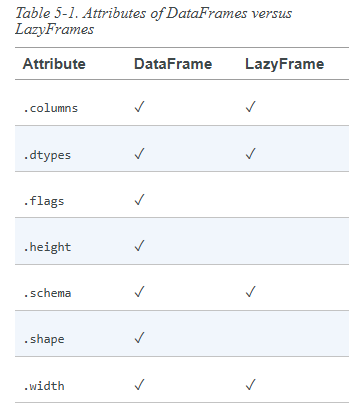

## Aggregation Methods

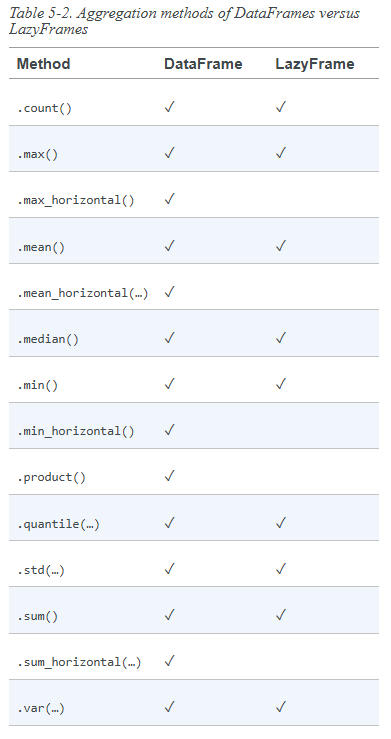

## Descriptive methods

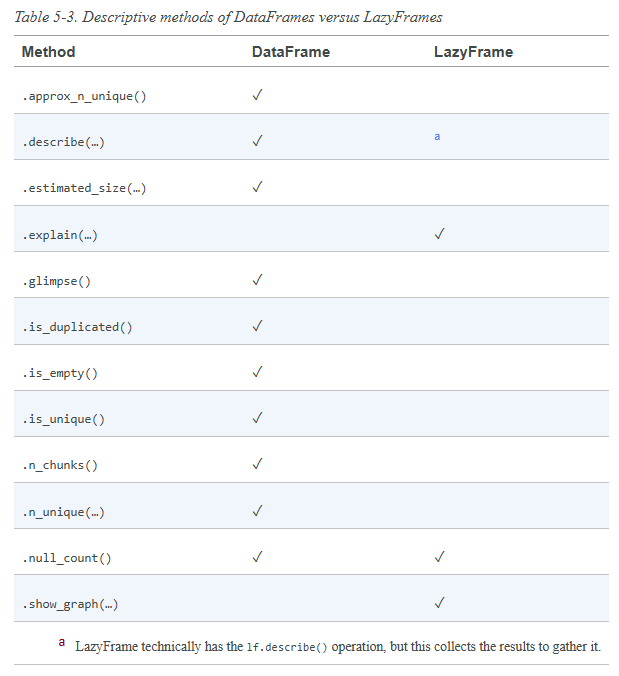

## GroupBy methods

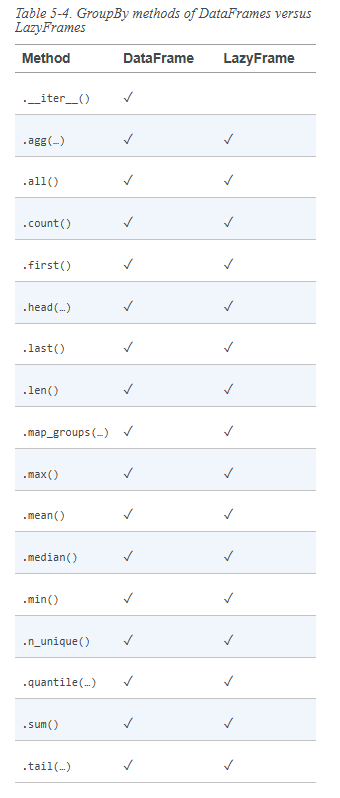

## Exporting Methods

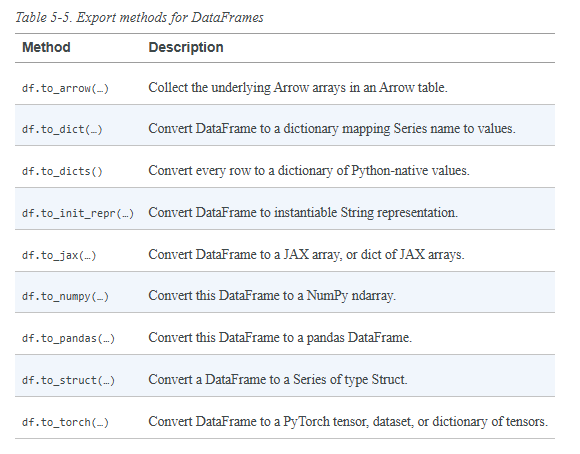

## Manipulation and Selection Methods

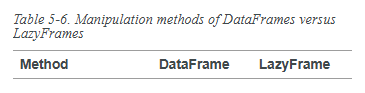

## Miscellaneous Methods

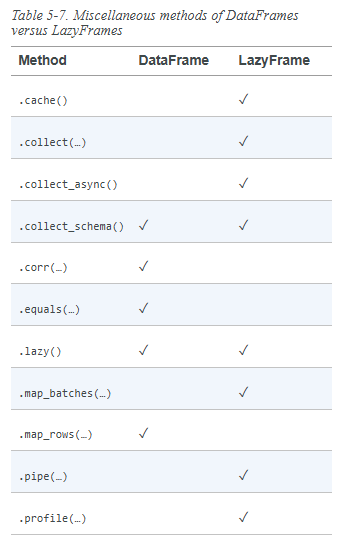

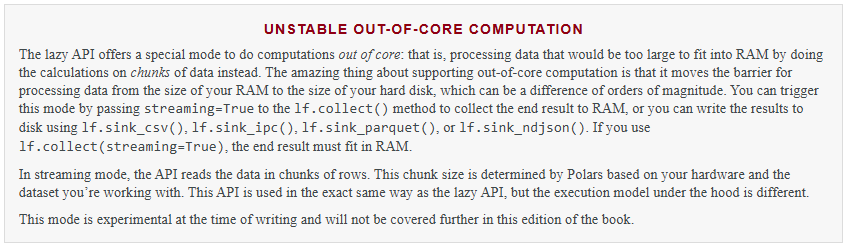

## Tips and Tricks

### Joining a DataFrame with a LazyFrame

In [7]:
big_sales_data = pl.LazyFrame(
    {"sale_id": [101, 102, 103], "amount": [250, 150, 300]}
)

sales_metadata = pl.DataFrame(
    {"sale_id": [101, 102, 103], "category": ["A", "B", "A"]}
)

big_sales_data.join(sales_metadata.lazy(), on="sale_id").collect()

sale_id,amount,category
i64,i64,str
101,250,"""A"""
102,150,"""B"""
103,300,"""A"""


### Caching Intermittent Results

In [8]:
lf = pl.LazyFrame({"col1": [1, 2, 3], "col2": [4, 5, 6]})

lf = lf.collect().lazy()  # Cache the LF
print(lf.collect())

print(lf.with_columns(pl.col("col1") + 1).collect()) # This line makes use of the cached LF.

shape: (3, 2)
┌──────┬──────┐
│ col1 ┆ col2 │
│ ---  ┆ ---  │
│ i64  ┆ i64  │
╞══════╪══════╡
│ 1    ┆ 4    │
│ 2    ┆ 5    │
│ 3    ┆ 6    │
└──────┴──────┘
shape: (3, 2)
┌──────┬──────┐
│ col1 ┆ col2 │
│ ---  ┆ ---  │
│ i64  ┆ i64  │
╞══════╪══════╡
│ 2    ┆ 4    │
│ 3    ┆ 5    │
│ 4    ┆ 6    │
└──────┴──────┘


## Reading and Writing Data

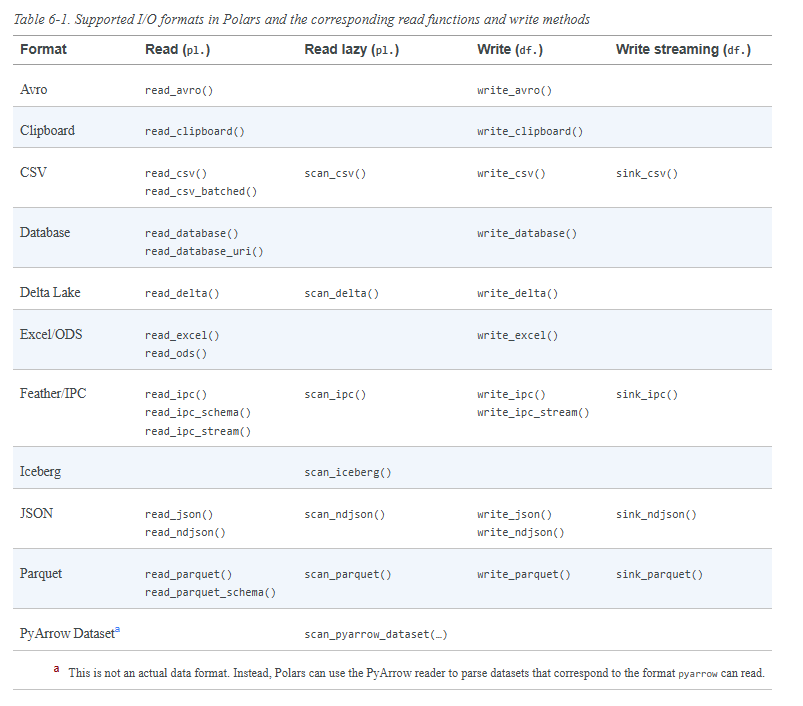

In [4]:
!cat data/penguins.csv

"cat" ­Ґ пў«пҐвбп ў­гваҐ­­Ґ© Ё«Ё ў­Ґи­Ґ©
Є®¬ ­¤®©, ЁбЇ®«­пҐ¬®© Їа®Ја ¬¬®© Ё«Ё Ї ЄҐв­л¬ д ©«®¬.


In [5]:
penguins = pl.read_csv('data/penguins.csv'); penguins

rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
i64,str,str,str,str,str,str,str,i64
1,"""Adelie""","""Torgersen""","""39.1""","""18.7""","""181""","""3750""","""male""",2007
2,"""Adelie""","""Torgersen""","""39.5""","""17.4""","""186""","""3800""","""female""",2007
3,"""Adelie""","""Torgersen""","""40.3""","""18""","""195""","""3250""","""female""",2007
4,"""Adelie""","""Torgersen""","""NA""","""NA""","""NA""","""NA""","""NA""",2007
5,"""Adelie""","""Torgersen""","""36.7""","""19.3""","""193""","""3450""","""female""",2007
…,…,…,…,…,…,…,…,…
340,"""Chinstrap""","""Dream""","""55.8""","""19.8""","""207""","""4000""","""male""",2009
341,"""Chinstrap""","""Dream""","""43.5""","""18.1""","""202""","""3400""","""female""",2009
342,"""Chinstrap""","""Dream""","""49.6""","""18.2""","""193""","""3775""","""male""",2009


In [6]:
penguins = pl.read_csv('data/penguins.csv', null_values='NA'); penguins

rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
i64,str,str,f64,f64,i64,i64,str,i64
1,"""Adelie""","""Torgersen""",39.1,18.7,181,3750,"""male""",2007
2,"""Adelie""","""Torgersen""",39.5,17.4,186,3800,"""female""",2007
3,"""Adelie""","""Torgersen""",40.3,18.0,195,3250,"""female""",2007
4,"""Adelie""","""Torgersen""",null,null,null,null,null,2007
5,"""Adelie""","""Torgersen""",36.7,19.3,193,3450,"""female""",2007
…,…,…,…,…,…,…,…,…
340,"""Chinstrap""","""Dream""",55.8,19.8,207,4000,"""male""",2009
341,"""Chinstrap""","""Dream""",43.5,18.1,202,3400,"""female""",2009
342,"""Chinstrap""","""Dream""",49.6,18.2,193,3775,"""male""",2009


In [10]:
(
    penguins
        .null_count()
        .transpose(include_header=True, column_names=['null_count'])
)

column,null_count
str,u32
"""rowid""",0
"""species""",0
"""island""",0
"""bill_length_mm""",2
"""bill_depth_mm""",2
"""flipper_length_mm""",2
"""body_mass_g""",2
"""sex""",11
"""year""",0


In [12]:
pl.read_csv('data/directors.csv', encoding='EUC-CN')

name,born,country
str,i64,str
"""考侯""",1930,"""泣塑"""
"""Verhoeven""",1938,"""オランダ"""
"""弟宏""",1942,"""泣塑"""
"""Tarantino""",1963,"""势柜"""


In [16]:
def detect_encoding(filename: str) -> str:
    'return the most probable character encoding for a file.'
    with open(filename, 'rb') as f:
        raw_data = f.read()
        result = chardet.detect(raw_data)
        return result['encoding']

In [17]:
detect_encoding('data/directors.csv')

'EUC-JP'

In [18]:
pl.read_csv('data/directors.csv', encoding='EUC-JP')

name,born,country
str,i64,str
"""深作""",1930,"""日本"""
"""Verhoeven""",1938,"""オランダ"""
"""宮崎""",1942,"""日本"""
"""Tarantino""",1963,"""米国"""


In [21]:
songs = pl.read_excel('data/top2000-2023.xlsx', engine='calamine'); songs

positie,titel,artiest,jaar
i64,str,str,i64
1,"""Bohemian Rhapsody""","""Queen""",1975
2,"""Roller Coaster""","""Danny Vera""",2019
3,"""Hotel California""","""Eagles""",1977
4,"""Piano Man""","""Billy Joel""",1974
5,"""Fix You""","""Coldplay""",2005
…,…,…,…
1996,"""Charlie Brown""","""Coldplay""",2011
1997,"""Beast Of Burden""","""Bette Midler""",1984
1998,"""It Was A Very Good Year""","""Frank Sinatra""",1968


In [22]:
pl.read_csv('data/stock/nvda/201?.csv')

symbol,date,open,high,low,close,adj close,volume
str,str,f64,f64,f64,f64,f64,i64
"""NVDA""","""2010-01-04""",4.6275,4.655,4.5275,4.6225,4.240429,80020400
"""NVDA""","""2010-01-05""",4.605,4.74,4.605,4.69,4.30235,72864800
"""NVDA""","""2010-01-06""",4.6875,4.73,4.6425,4.72,4.32987,64916800
"""NVDA""","""2010-01-07""",4.695,4.715,4.5925,4.6275,4.245015,54779200
"""NVDA""","""2010-01-08""",4.59,4.67,4.5625,4.6375,4.254189,47816800
…,…,…,…,…,…,…,…
"""NVDA""","""2019-12-24""",59.549999,59.827499,59.205002,59.654999,59.422798,13886400
"""NVDA""","""2019-12-26""",59.689999,60.080002,59.5,59.797501,59.564739,18285200
"""NVDA""","""2019-12-27""",59.950001,60.084999,58.952499,59.217499,58.987,25464400


In [27]:
all_stocks = pl.read_csv('data/stock/**/*.csv'); all_stocks

symbol,date,open,high,low,close,adj close,volume
str,str,f64,f64,f64,f64,f64,i64
"""ASML""","""1999-01-04""",11.765625,12.28125,11.765625,12.140625,7.522523,1801867
"""ASML""","""1999-01-05""",11.859375,14.25,11.71875,13.96875,8.655257,8241600
"""ASML""","""1999-01-06""",14.25,17.601563,14.203125,16.875,10.456018,16400267
"""ASML""","""1999-01-07""",14.742188,17.8125,14.53125,16.851563,10.441495,17722133
"""ASML""","""1999-01-08""",16.078125,16.289063,15.023438,15.796875,9.787995,10696000
…,…,…,…,…,…,…,…
"""TSM""","""2023-06-26""",102.019997,103.040001,100.089996,100.110001,99.125954,8560000
"""TSM""","""2023-06-27""",101.150002,102.790001,100.019997,102.080002,101.076591,9732000
"""TSM""","""2023-06-28""",100.5,101.879997,100.220001,100.919998,99.927986,8160900


In [29]:
filenames = [
    f'data/stock/asml/{year}.csv'
    for year in range(1999, 2024)
    if calendar.isleap(year)
]; filenames

['data/stock/asml/2000.csv',
 'data/stock/asml/2004.csv',
 'data/stock/asml/2008.csv',
 'data/stock/asml/2012.csv',
 'data/stock/asml/2016.csv',
 'data/stock/asml/2020.csv']

In [30]:
pl.concat(pl.read_csv(f) for f in filenames)

symbol,date,open,high,low,close,adj close,volume
str,str,f64,f64,f64,f64,f64,i64
"""ASML""","""2000-01-03""",43.875,43.875,41.90625,43.640625,27.040424,1121600
"""ASML""","""2000-01-04""",41.953125,42.5625,40.59375,40.734375,25.239666,968800
"""ASML""","""2000-01-05""",39.28125,39.703125,37.757813,39.609375,24.542597,1458133
"""ASML""","""2000-01-06""",36.75,37.59375,35.226563,37.171875,23.032274,3517867
"""ASML""","""2000-01-07""",36.867188,38.0625,36.65625,38.015625,23.555077,1631200
…,…,…,…,…,…,…,…
"""ASML""","""2020-12-24""",478.950012,484.600006,477.079987,483.089996,468.836365,271900
"""ASML""","""2020-12-28""",487.140015,488.720001,478.429993,480.23999,466.070496,449300
"""ASML""","""2020-12-29""",489.450012,489.450012,482.51001,484.01001,469.729218,377200


In [34]:
%%time
trips = pl.read_parquet('data/taxi/yellow_tripdata*.parquet'); trips

CPU times: total: 44.3 s
Wall time: 6.11 s


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
i64,datetime[ns],datetime[ns],f64,f64,f64,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,2022-01-01 00:35:40,2022-01-01 00:53:29,2.0,3.8,1.0,"""N""",142,236,1,14.5,3.0,0.5,3.65,0.0,0.3,21.95,2.5,0.0
1,2022-01-01 00:33:43,2022-01-01 00:42:07,1.0,2.1,1.0,"""N""",236,42,1,8.0,0.5,0.5,4.0,0.0,0.3,13.3,0.0,0.0
2,2022-01-01 00:53:21,2022-01-01 01:02:19,1.0,0.97,1.0,"""N""",166,166,1,7.5,0.5,0.5,1.76,0.0,0.3,10.56,0.0,0.0
2,2022-01-01 00:25:21,2022-01-01 00:35:23,1.0,1.09,1.0,"""N""",114,68,2,8.0,0.5,0.5,0.0,0.0,0.3,11.8,2.5,0.0
2,2022-01-01 00:36:48,2022-01-01 01:14:20,1.0,4.3,1.0,"""N""",68,163,1,23.5,0.5,0.5,3.0,0.0,0.3,30.3,2.5,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2022-12-31 23:46:00,2023-01-01 00:11:00,null,11.56,null,null,16,36,0,39.55,0.0,0.5,8.21,0.0,1.0,49.26,null,null
2,2022-12-31 23:13:24,2022-12-31 23:29:08,null,5.06,null,null,75,50,0,26.23,0.0,0.5,0.0,0.0,1.0,30.23,null,null
2,2022-12-31 23:00:49,2022-12-31 23:26:57,null,13.35,null,null,168,197,0,47.73,0.0,0.5,9.85,0.0,1.0,59.08,null,null


In [36]:
pokedex = pl.read_json('data/pokedex.json'); pokedex

pokemon
list[struct[17]]
"[{1,""001"",""Bulbasaur"",""http://www.serebii.net/pokemongo/pokemon/001.png"",[""Grass"", ""Poison""],""0.71 m"",""6.9 kg"",""Bulbasaur Candy"",""2 km"",0.69,69.0,""20:00"",[1.58],[""Fire"", ""Ice"", … ""Psychic""],null,25,[{""002"",""Ivysaur""}, {""003"",""Venusaur""}]}, {2,""002"",""Ivysaur"",""http://www.serebii.net/pokemongo/pokemon/002.png"",[""Grass"", ""Poison""],""0.99 m"",""13.0 kg"",""Bulbasaur Candy"",""Not in Eggs"",0.042,4.2,""07:00"",[1.2, 1.6],[""Fire"", ""Ice"", … ""Psychic""],[{""001"",""Bulbasaur""}],100,[{""003"",""Venusaur""}]}, … {151,""151"",""Mew"",""http://www.serebii.net/pokemongo/pokemon/151.png"",[""Psychic""],""0.41 m"",""4.0 kg"",""None"",""Not in Eggs"",0.0,0.0,""N/A"",null,[""Bug"", ""Ghost"", ""Dark""],null,null,null}]"


In [37]:
pokedex.explode('pokemon')

pokemon
struct[17]
"{1,""001"",""Bulbasaur"",""http://www.serebii.net/pokemongo/pokemon/001.png"",[""Grass"", ""Poison""],""0.71 m"",""6.9 kg"",""Bulbasaur Candy"",""2 km"",0.69,69.0,""20:00"",[1.58],[""Fire"", ""Ice"", … ""Psychic""],null,25,[{""002"",""Ivysaur""}, {""003"",""Venusaur""}]}"
"{2,""002"",""Ivysaur"",""http://www.serebii.net/pokemongo/pokemon/002.png"",[""Grass"", ""Poison""],""0.99 m"",""13.0 kg"",""Bulbasaur Candy"",""Not in Eggs"",0.042,4.2,""07:00"",[1.2, 1.6],[""Fire"", ""Ice"", … ""Psychic""],[{""001"",""Bulbasaur""}],100,[{""003"",""Venusaur""}]}"
"{3,""003"",""Venusaur"",""http://www.serebii.net/pokemongo/pokemon/003.png"",[""Grass"", ""Poison""],""2.01 m"",""100.0 kg"",""Bulbasaur Candy"",""Not in Eggs"",0.017,1.7,""11:30"",null,[""Fire"", ""Ice"", … ""Psychic""],[{""001"",""Bulbasaur""}, {""002"",""Ivysaur""}],null,null}"
"{4,""004"",""Charmander"",""http://www.serebii.net/pokemongo/pokemon/004.png"",[""Fire""],""0.61 m"",""8.5 kg"",""Charmander Candy"",""2 km"",0.253,25.3,""08:45"",[1.65],[""Water"", ""Ground"", ""Rock""],null,25,[{""005"",""Charmeleon""}, {""006"",""Charizard""}]}"
"{5,""005"",""Charmeleon"",""http://www.serebii.net/pokemongo/pokemon/005.png"",[""Fire""],""1.09 m"",""19.0 kg"",""Charmander Candy"",""Not in Eggs"",0.012,1.2,""19:00"",[1.79],[""Water"", ""Ground"", ""Rock""],[{""004"",""Charmander""}],100,[{""006"",""Charizard""}]}"
…
"{147,""147"",""Dratini"",""http://www.serebii.net/pokemongo/pokemon/147.png"",[""Dragon""],""1.80 m"",""3.3 kg"",""Dratini Candy"",""10 km"",0.3,30.0,""06:41"",[1.83, 1.84],[""Ice"", ""Dragon"", ""Fairy""],null,25,[{""148"",""Dragonair""}, {""149"",""Dragonite""}]}"
"{148,""148"",""Dragonair"",""http://www.serebii.net/pokemongo/pokemon/148.png"",[""Dragon""],""3.99 m"",""16.5 kg"",""Dratini Candy"",""Not in Eggs"",0.02,2.0,""11:57"",[2.05],[""Ice"", ""Dragon"", ""Fairy""],[{""147"",""Dratini""}],100,[{""149"",""Dragonite""}]}"
"{149,""149"",""Dragonite"",""http://www.serebii.net/pokemongo/pokemon/149.png"",[""Dragon"", ""Flying""],""2.21 m"",""210.0 kg"",""Dratini Candy"",""Not in Eggs"",0.0011,0.11,""23:38"",null,[""Ice"", ""Rock"", … ""Fairy""],[{""147"",""Dratini""}, {""148"",""Dragonair""}],null,null}"


In [38]:
pokedex.explode('pokemon').unnest('pokemon')

id,num,name,img,type,height,weight,candy,egg,spawn_chance,avg_spawns,spawn_time,multipliers,weaknesses,prev_evolution,candy_count,next_evolution
i64,str,str,str,list[str],str,str,str,str,f64,f64,str,list[f64],list[str],list[struct[2]],i64,list[struct[2]]
1,"""001""","""Bulbasaur""","""http://www.serebii.net/pokemon…","[""Grass"", ""Poison""]","""0.71 m""","""6.9 kg""","""Bulbasaur Candy""","""2 km""",0.69,69.0,"""20:00""",[1.58],"[""Fire"", ""Ice"", … ""Psychic""]",null,25,"[{""002"",""Ivysaur""}, {""003"",""Venusaur""}]"
2,"""002""","""Ivysaur""","""http://www.serebii.net/pokemon…","[""Grass"", ""Poison""]","""0.99 m""","""13.0 kg""","""Bulbasaur Candy""","""Not in Eggs""",0.042,4.2,"""07:00""","[1.2, 1.6]","[""Fire"", ""Ice"", … ""Psychic""]","[{""001"",""Bulbasaur""}]",100,"[{""003"",""Venusaur""}]"
3,"""003""","""Venusaur""","""http://www.serebii.net/pokemon…","[""Grass"", ""Poison""]","""2.01 m""","""100.0 kg""","""Bulbasaur Candy""","""Not in Eggs""",0.017,1.7,"""11:30""",null,"[""Fire"", ""Ice"", … ""Psychic""]","[{""001"",""Bulbasaur""}, {""002"",""Ivysaur""}]",null,null
4,"""004""","""Charmander""","""http://www.serebii.net/pokemon…","[""Fire""]","""0.61 m""","""8.5 kg""","""Charmander Candy""","""2 km""",0.253,25.3,"""08:45""",[1.65],"[""Water"", ""Ground"", ""Rock""]",null,25,"[{""005"",""Charmeleon""}, {""006"",""Charizard""}]"
5,"""005""","""Charmeleon""","""http://www.serebii.net/pokemon…","[""Fire""]","""1.09 m""","""19.0 kg""","""Charmander Candy""","""Not in Eggs""",0.012,1.2,"""19:00""",[1.79],"[""Water"", ""Ground"", ""Rock""]","[{""004"",""Charmander""}]",100,"[{""006"",""Charizard""}]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
147,"""147""","""Dratini""","""http://www.serebii.net/pokemon…","[""Dragon""]","""1.80 m""","""3.3 kg""","""Dratini Candy""","""10 km""",0.3,30.0,"""06:41""","[1.83, 1.84]","[""Ice"", ""Dragon"", ""Fairy""]",null,25,"[{""148"",""Dragonair""}, {""149"",""Dragonite""}]"
148,"""148""","""Dragonair""","""http://www.serebii.net/pokemon…","[""Dragon""]","""3.99 m""","""16.5 kg""","""Dratini Candy""","""Not in Eggs""",0.02,2.0,"""11:57""",[2.05],"[""Ice"", ""Dragon"", ""Fairy""]","[{""147"",""Dratini""}]",100,"[{""149"",""Dragonite""}]"
149,"""149""","""Dragonite""","""http://www.serebii.net/pokemon…","[""Dragon"", ""Flying""]","""2.21 m""","""210.0 kg""","""Dratini Candy""","""Not in Eggs""",0.0011,0.11,"""23:38""",null,"[""Ice"", ""Rock"", … ""Fairy""]","[{""147"",""Dratini""}, {""148"",""Dragonair""}]",null,null


In [39]:
pokedex.explode('pokemon').unnest('pokemon').select('id', 'name', 'type', 'height', 'weight')

id,name,type,height,weight
i64,str,list[str],str,str
1,"""Bulbasaur""","[""Grass"", ""Poison""]","""0.71 m""","""6.9 kg"""
2,"""Ivysaur""","[""Grass"", ""Poison""]","""0.99 m""","""13.0 kg"""
3,"""Venusaur""","[""Grass"", ""Poison""]","""2.01 m""","""100.0 kg"""
4,"""Charmander""","[""Fire""]","""0.61 m""","""8.5 kg"""
5,"""Charmeleon""","[""Fire""]","""1.09 m""","""19.0 kg"""
…,…,…,…,…
147,"""Dratini""","[""Dragon""]","""1.80 m""","""3.3 kg"""
148,"""Dragonair""","[""Dragon""]","""3.99 m""","""16.5 kg"""
149,"""Dragonite""","[""Dragon"", ""Flying""]","""2.21 m""","""210.0 kg"""


In [42]:
with open('data/wikimedia.ndjson') as f:
    pprint.pprint(json.loads(f.readline()))

{'$schema': '/mediawiki/recentchange/1.0.0',
 'bot': False,
 'comment': '/* League champions, runners-up and play-off finalists */',
 'id': 1659529639,
 'length': {'new': 91166, 'old': 91108},
 'meta': {'domain': 'en.wikipedia.org',
          'dt': '2023-07-29T07:51:39Z',
          'id': '0416300b-980c-45bb-b0a2-c9d7a9e2b7eb',
          'offset': 4820784717,
          'partition': 0,
          'request_id': 'ea0541fb-4e72-4fc3-82f0-6c26651b2043',
          'stream': 'mediawiki.recentchange',
          'topic': 'eqiad.mediawiki.recentchange',
          'uri': 'https://en.wikipedia.org/wiki/EFL_Championship'},
 'minor': False,
 'namespace': 0,
 'notify_url': 'https://en.wikipedia.org/w/index.php?diff=1167689309&oldid=1166824248',
 'parsedcomment': '<span dir="auto"><span class="autocomment"><a '
                  'href="/wiki/EFL_Championship#League_champions,_runners-up_and_play-off_finalists" '
                  'title="EFL Championship">в†’вЂЋLeague champions, runners-up '
           

In [43]:
wikimedia = pl.read_ndjson('data/wikimedia.ndjson'); wikimedia

$schema,meta,id,type,namespace,title,title_url,comment,timestamp,user,bot,notify_url,minor,length,revision,server_url,server_name,server_script_path,wiki,parsedcomment
str,struct[9],i64,str,i64,str,str,str,i64,str,bool,str,bool,struct[2],struct[2],str,str,str,str,str
"""/mediawiki/recentchange/1.0.0""","{""https://en.wikipedia.org/wiki/EFL_Championship"",""ea0541fb-4e72-4fc3-82f0-6c26651b2043"",""0416300b-980c-45bb-b0a2-c9d7a9e2b7eb"",""2023-07-29T07:51:39Z"",""en.wikipedia.org"",""mediawiki.recentchange"",""eqiad.mediawiki.recentchange"",0,4820784717}",1659529639,"""edit""",0,"""EFL Championship""","""https://en.wikipedia.org/wiki/…","""/* League champions, runners-u…",1690617099,"""87.12.215.232""",false,"""https://en.wikipedia.org/w/ind…",false,"{91108,91166}","{1166824248,1167689309}","""https://en.wikipedia.org""","""en.wikipedia.org""","""/w""","""enwiki""","""<span dir=""auto""><span class=""…"
"""/mediawiki/recentchange/1.0.0""","{""https://en.wikipedia.org/wiki/Lim_Sang-choon"",""01a0f468-7553-48db-b553-7ac392b2187c"",""97e4dc39-fb32-4774-9c9a-b2caea391c9e"",""2023-07-29T07:51:42Z"",""en.wikipedia.org"",""mediawiki.recentchange"",""eqiad.mediawiki.recentchange"",0,4820784731}",1659529640,"""edit""",0,"""Lim Sang-choon""","""https://en.wikipedia.org/wiki/…","""""",1690617102,"""Preferwiki""",false,"""https://en.wikipedia.org/w/ind…",false,"{9807,10480}","{1167689034,1167689310}","""https://en.wikipedia.org""","""en.wikipedia.org""","""/w""","""enwiki""",""""""
"""/mediawiki/recentchange/1.0.0""","{""https://en.wikipedia.org/wiki/Higher"",""5f053899-a2ab-4dec-8e98-1d01cd86093d"",""0da41aa2-ceb6-443f-8a0a-0633f83de6ec"",""2023-07-29T07:51:44Z"",""en.wikipedia.org"",""mediawiki.recentchange"",""eqiad.mediawiki.recentchange"",0,4820784748}",1659529642,"""edit""",0,"""Higher""","""https://en.wikipedia.org/wiki/…","""/* Albums */ add""",1690617104,"""Ss112""",false,"""https://en.wikipedia.org/w/ind…",false,"{5452,5548}","{1162509981,1167689312}","""https://en.wikipedia.org""","""en.wikipedia.org""","""/w""","""enwiki""","""<span dir=""auto""><span class=""…"
"""/mediawiki/recentchange/1.0.0""","{""https://en.wikipedia.org/wiki/International_Poker_Rules"",""10c4886c-95f5-4cd2-8db9-333cb45f041b"",""af9cc405-26b2-485d-b20c-edd21b2a2a4c"",""2023-07-29T07:51:44Z"",""en.wikipedia.org"",""mediawiki.recentchange"",""eqiad.mediawiki.recentchange"",0,4820784763}",1659529643,"""edit""",0,"""International Poker Rules""","""https://en.wikipedia.org/wiki/…","""Nominated for deletion; see [[…",1690617104,"""Piotrus""",false,"""https://en.wikipedia.org/w/ind…",false,"{2452,2896}","{1055827921,1167689313}","""https://en.wikipedia.org""","""en.wikipedia.org""","""/w""","""enwiki""","""Nominated for deletion; see <a…"
"""/mediawiki/recentchange/1.0.0""","{""https://en.wikipedia.org/wiki/Abdul_Hamid_Khan_Bhashani"",""198e47ae-fa33-4059-970a-550536e7bc7c"",""2012e36f-9fa1-49dc-ba68-5946de740cd4"",""2023-07-29T07:51:45Z"",""en.wikipedia.org"",""mediawiki.recentchange"",""eqiad.mediawiki.recentchange"",0,4820784800}",1659529653,"""edit""",0,"""Abdul Hamid Khan Bhashani""","""https://en.wikipedia.org/wiki/…","""Rescuing 1 sources and tagging…",1690617105,"""InternetArchiveBot""",true,"""https://en.wikipedia.org/w/ind…",false,"{31503,31687}","{1163358967,1167689318}","""https://en.wikipedia.org""","""en.wikipedia.org""","""/w""","""enwiki""","""Rescuing 1 sources and tagging…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""/mediawiki/recentchange/1.0.0""","{""https://en.wikipedia.org/wiki/Havering_Residents_Association"",""d563edd1-2a19-491b-9604-aea1b7c57a67"",""f5b5b53d-8024-4c4d-810b-e3c04b8f2392"",""2023-07-29T07:53:58Z"",""en.wikipedia.org"",""mediawiki.recentchange"",""eqiad.mediawiki.recentchange"",0,4820788373}",1659529961,"""edit""",0,"""Havering Residents Association""","""https://en.wikipedia.org/wiki/…","""/* 2018 election */ +map""",1690617238,"""MRSC""",false,"""https://en.wikipedia.org/w/ind…",false,"{7590,7707}","{1167689281,1167689476}"

In [46]:
wikimedia.rename(dict(id='edit_id')).head(3)

$schema,meta,edit_id,type,namespace,title,title_url,comment,timestamp,user,bot,notify_url,minor,length,revision,server_url,server_name,server_script_path,wiki,parsedcomment
str,struct[9],i64,str,i64,str,str,str,i64,str,bool,str,bool,struct[2],struct[2],str,str,str,str,str
"""/mediawiki/recentchange/1.0.0""","{""https://en.wikipedia.org/wiki/EFL_Championship"",""ea0541fb-4e72-4fc3-82f0-6c26651b2043"",""0416300b-980c-45bb-b0a2-c9d7a9e2b7eb"",""2023-07-29T07:51:39Z"",""en.wikipedia.org"",""mediawiki.recentchange"",""eqiad.mediawiki.recentchange"",0,4820784717}",1659529639,"""edit""",0,"""EFL Championship""","""https://en.wikipedia.org/wiki/…","""/* League champions, runners-u…",1690617099,"""87.12.215.232""",false,"""https://en.wikipedia.org/w/ind…",false,"{91108,91166}","{1166824248,1167689309}","""https://en.wikipedia.org""","""en.wikipedia.org""","""/w""","""enwiki""","""<span dir=""auto""><span class=""…"
"""/mediawiki/recentchange/1.0.0""","{""https://en.wikipedia.org/wiki/Lim_Sang-choon"",""01a0f468-7553-48db-b553-7ac392b2187c"",""97e4dc39-fb32-4774-9c9a-b2caea391c9e"",""2023-07-29T07:51:42Z"",""en.wikipedia.org"",""mediawiki.recentchange"",""eqiad.mediawiki.recentchange"",0,4820784731}",1659529640,"""edit""",0,"""Lim Sang-choon""","""https://en.wikipedia.org/wiki/…","""""",1690617102,"""Preferwiki""",false,"""https://en.wikipedia.org/w/ind…",false,"{9807,10480}","{1167689034,1167689310}","""https://en.wikipedia.org""","""en.wikipedia.org""","""/w""","""enwiki""",""""""
"""/mediawiki/recentchange/1.0.0""","{""https://en.wikipedia.org/wiki/Higher"",""5f053899-a2ab-4dec-8e98-1d01cd86093d"",""0da41aa2-ceb6-443f-8a0a-0633f83de6ec"",""2023-07-29T07:51:44Z"",""en.wikipedia.org"",""mediawiki.recentchange"",""eqiad.mediawiki.recentchange"",0,4820784748}",1659529642,"""edit""",0,"""Higher""","""https://en.wikipedia.org/wiki/…","""/* Albums */ add""",1690617104,"""Ss112""",false,"""https://en.wikipedia.org/w/ind…",false,"{5452,5548}","{1162509981,1167689312}","""https://en.wikipedia.org""","""en.wikipedia.org""","""/w""","""enwiki""","""<span dir=""auto""><span class=""…"


In [47]:
wikimedia.rename(dict(id='edit_id')).unnest('meta').head(3)

$schema,uri,request_id,id,dt,domain,stream,topic,partition,offset,edit_id,type,namespace,title,title_url,comment,timestamp,user,bot,notify_url,minor,length,revision,server_url,server_name,server_script_path,wiki,parsedcomment
str,str,str,str,str,str,str,str,i64,i64,i64,str,i64,str,str,str,i64,str,bool,str,bool,struct[2],struct[2],str,str,str,str,str
"""/mediawiki/recentchange/1.0.0""","""https://en.wikipedia.org/wiki/…","""ea0541fb-4e72-4fc3-82f0-6c2665…","""0416300b-980c-45bb-b0a2-c9d7a9…","""2023-07-29T07:51:39Z""","""en.wikipedia.org""","""mediawiki.recentchange""","""eqiad.mediawiki.recentchange""",0,4820784717,1659529639,"""edit""",0,"""EFL Championship""","""https://en.wikipedia.org/wiki/…","""/* League champions, runners-u…",1690617099,"""87.12.215.232""",false,"""https://en.wikipedia.org/w/ind…",false,"{91108,91166}","{1166824248,1167689309}","""https://en.wikipedia.org""","""en.wikipedia.org""","""/w""","""enwiki""","""<span dir=""auto""><span class=""…"
"""/mediawiki/recentchange/1.0.0""","""https://en.wikipedia.org/wiki/…","""01a0f468-7553-48db-b553-7ac392…","""97e4dc39-fb32-4774-9c9a-b2caea…","""2023-07-29T07:51:42Z""","""en.wikipedia.org""","""mediawiki.recentchange""","""eqiad.mediawiki.recentchange""",0,4820784731,1659529640,"""edit""",0,"""Lim Sang-choon""","""https://en.wikipedia.org/wiki/…","""""",1690617102,"""Preferwiki""",false,"""https://en.wikipedia.org/w/ind…",false,"{9807,10480}","{1167689034,1167689310}","""https://en.wikipedia.org""","""en.wikipedia.org""","""/w""","""enwiki""",""""""
"""/mediawiki/recentchange/1.0.0""","""https://en.wikipedia.org/wiki/…","""5f053899-a2ab-4dec-8e98-1d01cd…","""0da41aa2-ceb6-443f-8a0a-0633f8…","""2023-07-29T07:51:44Z""","""en.wikipedia.org""","""mediawiki.recentchange""","""eqiad.mediawiki.recentchange""",0,4820784748,1659529642,"""edit""",0,"""Higher""","""https://en.wikipedia.org/wiki/…","""/* Albums */ add""",1690617104,"""Ss112""",false,"""https://en.wikipedia.org/w/ind…",false,"{5452,5548}","{1162509981,1167689312}","""https://en.wikipedia.org""","""en.wikipedia.org""","""/w""","""enwiki""","""<span dir=""auto""><span class=""…"


In [49]:
wikimedia.rename(dict(id='edit_id')).unnest('meta').select('timestamp', 'title', 'user', 'comment')

timestamp,title,user,comment
i64,str,str,str
1690617099,"""EFL Championship""","""87.12.215.232""","""/* League champions, runners-u…"
1690617102,"""Lim Sang-choon""","""Preferwiki""",""""""
1690617104,"""Higher""","""Ss112""","""/* Albums */ add"""
1690617104,"""International Poker Rules""","""Piotrus""","""Nominated for deletion; see [[…"
1690617105,"""Abdul Hamid Khan Bhashani""","""InternetArchiveBot""","""Rescuing 1 sources and tagging…"
…,…,…,…
1690617238,"""Havering Residents Association""","""MRSC""","""/* 2018 election */ +map"""
1690617235,"""Olha Kharlan""","""2603:7000:2101:AA00:2C88:EF86:…","""Ce"""
1690617238,"""Mukim Kota Batu""","""Pangalau""",""""""


In [58]:
url = 'https://en.wikipedia.org/wiki/List_of_Latin_abbreviations'
pl.from_pandas(pd.read_html(requests.get(url, verify=False).content)[0])

C:\Users\seliverstovdi\AppData\Roaming\Python\Python313\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'en.wikipedia.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings


abbreviation,Latin,translation,usage and notes
str,str,str,str
"""AD""","""anno Domini""","""""in the year of the Lord""""","""Used to label or number years …"
"""a.i.""","""ad interim""","""""temporarily""""","""Used in business organizationa…"
"""a.m.""","""ante meridiem""","""""before midday""[1]""","""Used on the twelve-hour clock …"
"""ca. c.""","""circa""","""""around"", ""about"", ""approximat…","""Used with dates to indicate ""a…"
"""Cap.""","""capitulus""","""""chapter""""","""Used before a chapter number o…"
…,…,…,…
"""SOS""","""si opus sit""","""""if there is need"", ""if occasi…","""A prescription indication that…"
"""sic""","""sic""","""""thus""""","""Used when quoting text that co…"
"""stat.""","""statim""","""""immediately""""","""Often used in medical contexts…"


In [63]:
pl.read_database_uri(
    query='''
        select
            f.film_id,
            f.title,
            c.name as category,
            f.rating,
            f.length / 60.0 as length
        from
            film as f,
            film_category as fc,
            category as c
        where
            fc.film_id = f.film_id
            and fc.category_id = c.category_id
        limit 10''',
    uri='sqlite:::data/sakila.db',)

film_id,title,category,rating,length
i64,str,str,str,f64
1,"""ACADEMY DINOSAUR""","""Documentary""","""PG""",1.433333
2,"""ACE GOLDFINGER""","""Horror""","""G""",0.8
3,"""ADAPTATION HOLES""","""Documentary""","""NC-17""",0.833333
4,"""AFFAIR PREJUDICE""","""Horror""","""G""",1.95
5,"""AFRICAN EGG""","""Family""","""G""",2.166667
6,"""AGENT TRUMAN""","""Foreign""","""PG""",2.816667
7,"""AIRPLANE SIERRA""","""Comedy""","""PG-13""",1.033333
8,"""AIRPORT POLLOCK""","""Horror""","""R""",0.9
9,"""ALABAMA DEVIL""","""Horror""","""PG-13""",1.9


In [3]:
db = 'sqlite:::data/sakila.db'
films = pl.read_database_uri('select * from film', db)
film_categories = pl.read_database_uri('select * from film_category', db)
categories = pl.read_database_uri('select * from category', db)

In [4]:
(
    films
        .join(film_categories, on='film_id', suffix='_fc')
        .join(categories, on='category_id', suffix='_c')
        .select(
            'film_id',
            'title',
            pl.col('name').alias('category'),
            'rating',
            pl.col('length') / 60,
    )
    .limit(10)
)

film_id,title,category,rating,length
i64,str,str,str,f64
1,"""ACADEMY DINOSAUR""","""Documentary""","""PG""",1.433333
2,"""ACE GOLDFINGER""","""Horror""","""G""",0.8
3,"""ADAPTATION HOLES""","""Documentary""","""NC-17""",0.833333
4,"""AFFAIR PREJUDICE""","""Horror""","""G""",1.95
5,"""AFRICAN EGG""","""Family""","""G""",2.166667
6,"""AGENT TRUMAN""","""Foreign""","""PG""",2.816667
7,"""AIRPLANE SIERRA""","""Comedy""","""PG-13""",1.033333
8,"""AIRPORT POLLOCK""","""Horror""","""R""",0.9
9,"""ALABAMA DEVIL""","""Horror""","""PG-13""",1.9


## Writing Data

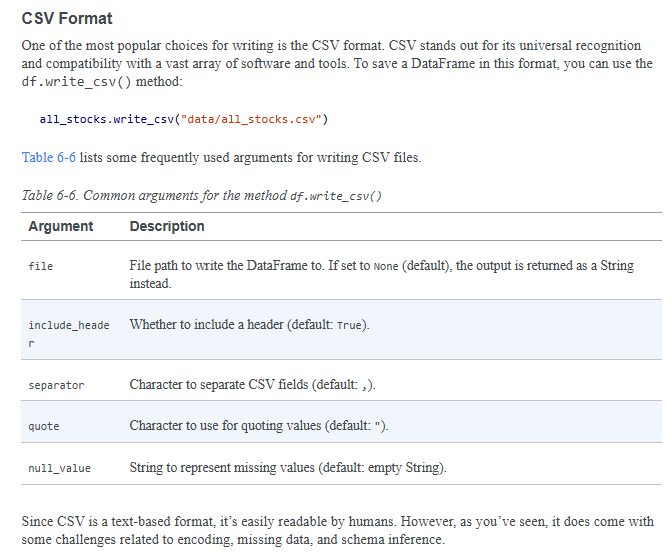

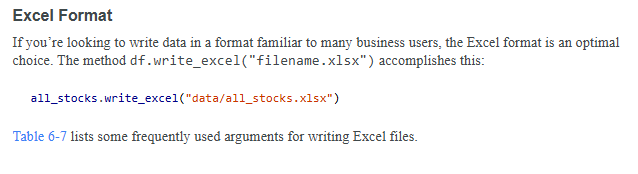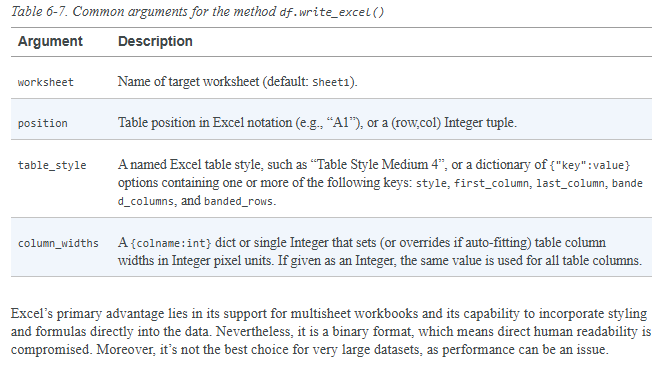

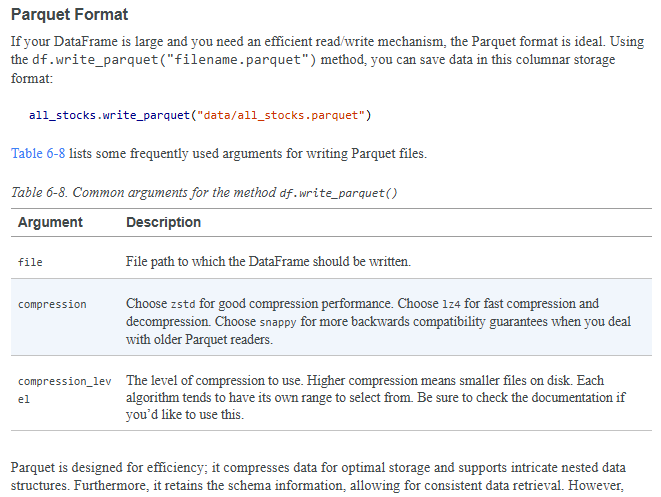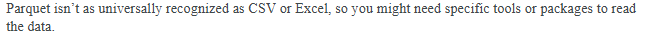

# Express

In [2]:
fruit = pl.read_csv('data/fruit.csv'); fruit

name,weight,color,is_round,origin
str,i64,str,bool,str
"""Avocado""",200,"""green""",false,"""South America"""
"""Banana""",120,"""yellow""",false,"""Asia"""
"""Blueberry""",1,"""blue""",false,"""North America"""
"""Cantaloupe""",2500,"""orange""",true,"""Africa"""
"""Cranberry""",2,"""red""",false,"""North America"""
"""Elderberry""",1,"""black""",false,"""Europe"""
"""Orange""",130,"""orange""",true,"""Asia"""
"""Papaya""",1000,"""orange""",false,"""South America"""
"""Peach""",150,"""orange""",true,"""Asia"""


In [3]:
fruit.select(
    pl.col('name'),
    pl.col('^.*or.*$'),
    pl.col('weight')/1000,
    'is_round')

name,color,origin,weight,is_round
str,str,str,f64,bool
"""Avocado""","""green""","""South America""",0.2,false
"""Banana""","""yellow""","""Asia""",0.12,false
"""Blueberry""","""blue""","""North America""",0.001,false
"""Cantaloupe""","""orange""","""Africa""",2.5,true
"""Cranberry""","""red""","""North America""",0.002,false
"""Elderberry""","""black""","""Europe""",0.001,false
"""Orange""","""orange""","""Asia""",0.13,true
"""Papaya""","""orange""","""South America""",1.0,false
"""Peach""","""orange""","""Asia""",0.15,true


In [4]:
fruit.with_columns(
    pl.lit(True).alias("is_fruit"),  
    is_berry=pl.col("name").str.ends_with("berry"),  
)

name,weight,color,is_round,origin,is_fruit,is_berry
str,i64,str,bool,str,bool,bool
"""Avocado""",200,"""green""",false,"""South America""",true,false
"""Banana""",120,"""yellow""",false,"""Asia""",true,false
"""Blueberry""",1,"""blue""",false,"""North America""",true,true
"""Cantaloupe""",2500,"""orange""",true,"""Africa""",true,false
"""Cranberry""",2,"""red""",false,"""North America""",true,true
"""Elderberry""",1,"""black""",false,"""Europe""",true,true
"""Orange""",130,"""orange""",true,"""Asia""",true,false
"""Papaya""",1000,"""orange""",false,"""South America""",true,false
"""Peach""",150,"""orange""",true,"""Asia""",true,false


In [5]:
fruit.filter(
    (pl.col('weight') > 1000) 
    & pl.col('is_round')
)

name,weight,color,is_round,origin
str,i64,str,bool,str
"""Cantaloupe""",2500,"""orange""",true,"""Africa"""
"""Watermelon""",5000,"""green""",true,"""Africa"""


In [6]:
fruit\
    .group_by(
        pl.col('origin').str.split(' ').list.last())\
    .agg(
        pl.len(),
        average_weight=pl.col('weight').mean()
    )

origin,len,average_weight
str,u32,f64
"""Asia""",3,133.333333
"""Europe""",1,1.0
"""America""",4,300.75
"""Africa""",2,3750.0


In [7]:
fruit.sort(
    pl.col('name').str.len_bytes(),
    descending=True)

name,weight,color,is_round,origin
str,i64,str,bool,str
"""Cantaloupe""",2500,"""orange""",true,"""Africa"""
"""Elderberry""",1,"""black""",false,"""Europe"""
"""Watermelon""",5000,"""green""",true,"""Africa"""
"""Blueberry""",1,"""blue""",false,"""North America"""
"""Cranberry""",2,"""red""",false,"""North America"""
"""Avocado""",200,"""green""",false,"""South America"""
"""Banana""",120,"""yellow""",false,"""Asia"""
"""Orange""",130,"""orange""",true,"""Asia"""
"""Papaya""",1000,"""orange""",false,"""South America"""


In [8]:
(
    pl.DataFrame(
        dict(a=[1, 2, 3], b=[0.4, 0.5, 0.6]))
    .with_columns(
        pl.all().mul(10).name.suffix('_times_10')
    )
)

a,b,a_times_10,b_times_10
i64,f64,i64,f64
1,0.4,10,4.0
2,0.5,20,5.0
3,0.6,30,6.0


In [9]:
(
    pl.DataFrame(
        dict(a=[1, 2, 3], b=[0.4, 0.5, 0.6]))
    .with_columns(
        pl.all().mul(10).name.suffix('_times_10')
            .meta.has_multiple_outputs()
    )
)

a,b,literal
i64,f64,bool
1,0.4,true
2,0.5,true
3,0.6,true


In [10]:
is_orange = (pl.col('color') == 'orange').alias('is_orange')

In [11]:
is_orange

<Expr ['[(col("color")) == ("orange")]…'] at 0x1CD071AE850>

In [12]:
fruit.with_columns(is_orange)

name,weight,color,is_round,origin,is_orange
str,i64,str,bool,str,bool
"""Avocado""",200,"""green""",false,"""South America""",false
"""Banana""",120,"""yellow""",false,"""Asia""",false
"""Blueberry""",1,"""blue""",false,"""North America""",false
"""Cantaloupe""",2500,"""orange""",true,"""Africa""",true
"""Cranberry""",2,"""red""",false,"""North America""",false
"""Elderberry""",1,"""black""",false,"""Europe""",false
"""Orange""",130,"""orange""",true,"""Asia""",true
"""Papaya""",1000,"""orange""",false,"""South America""",true
"""Peach""",150,"""orange""",true,"""Asia""",true


In [13]:
fruit.filter(is_orange)

name,weight,color,is_round,origin
str,i64,str,bool,str
"""Cantaloupe""",2500,"""orange""",true,"""Africa"""
"""Orange""",130,"""orange""",true,"""Asia"""
"""Papaya""",1000,"""orange""",false,"""South America"""
"""Peach""",150,"""orange""",true,"""Asia"""


In [14]:
fruit.group_by(is_orange).len()

is_orange,len
bool,u32
false,6
true,4


In [15]:
flowers = pl.DataFrame(
    dict(
        name=['Tiger lily', 'Blue flag', 'African marigold'],
        latin=['Lilium columbianum', 'Iris versiocolor', 'Tagetes erecta'],
        color=['orange', 'purple', 'orange'])
)

In [16]:
flowers.filter(is_orange)

name,latin,color
str,str,str
"""Tiger lily""","""Lilium columbianum""","""orange"""
"""African marigold""","""Tagetes erecta""","""orange"""
